In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
import itertools
import pickle
import copy
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, brier_score_loss 
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix

In [3]:
alpha = 0.5
gamma = 1
# seq_len = 1
seq_len = 3
learning_rate = 1e-4
batch_size = 128
max_epoch = 50
experiment_time = 10
limit_early_stop_count = 5
device = torch.device("cuda")

#DNR數據是否需要upsample
use_upsample = True

#['dod','dod_3day','dod_7day','dod_30day','dod_60day','dod_90day','DNR','Weaning_successful','SBT','dialysis']
#task_name_list = ['DNR']
#task_name_list = ['dod_7day']
#task_name_list = ['dod_30day']
#task_name_list = ['dialysis']
#task_name_list = ['Weaning_successful']
#task_name_list = ['SBT']
#task_name_list = ['dod_3day']
#task_name_list = ['dod_90day']
#task_name_list = ['InvasiveVent']
#task_name_list = ['Vasopressor']
#task_name_list = ['dod_60day']

#task_name_list = ['DNR','dod_30day']
#task_name_list = ['DNR','dod_7day']
#task_name_list = ['DNR','dialysis']
#task_name_list = ['DNR','Vasopressor']
#task_name_list = ['DNR','InvasiveVent']
#task_name_list = ['DNR','SBT']
#task_name_list = ['DNR','Weaning_successful']
#task_name_list = ['DNR','dod_3day']
#task_name_list = ['DNR','dod_90day']
#task_name_list = ['DNR','dod_60day']

task_name_list = ['DNR','dod_30day','Vasopressor']
#task_name_list = ['DNR','dod_30day','InvasiveVent']
#task_name_list = ['DNR','dod_30day','dialysis']
#task_name_list = ['DNR','InvasiveVent','dialysis']
#task_name_list = ['DNR','InvasiveVent','Vasopressor']
#task_name_list = ['DNR','Vasopressor','dialysis']

#task_name_list = ['DNR','dod_30day','Vasopressor','InvasiveVent']
#task_name_list = ['DNR','dod_30day','Vasopressor','dialysis']
#task_name_list = ['DNR','dod_30day','Vasopressor','InvasiveVent','dialysis']



In [4]:
# #transfromer test : mean pooling

# import torch
# import torch.nn as nn
# import numpy as np

# class RNN_MTL(nn.Module):
#     def __init__(self, input_dim, task_name_list, window_size=3, dropout_ratio=0.1, nhead=4, num_layers=2):
#         super(RNN_MTL, self).__init__()
#         self.task_name_list = task_name_list
#         self.num_tasks = len(task_name_list)
#         self.dropout = nn.Dropout(dropout_ratio)
#         self.relu = nn.ReLU()
#         self.sigmoid = nn.Sigmoid()
#         hidden_dim = 256
#         output_size = 1

#         # Input embedding
#         self.input_fc = nn.Linear(input_dim, hidden_dim)

#         # Positional encoding
#         self.pos_encoder = nn.Parameter(torch.zeros(1, window_size, hidden_dim))

#         # Transformer Encoder
#         encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout_ratio)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         # Towers for each task
#         # 這裡維持您原始的 Flatten 接法，如果您採用了我之前的 Pooling 建議，請將這裡改為: nn.Linear(hidden_dim, 64)
#         self.task_fc0 = nn.ModuleList([nn.Linear(hidden_dim * window_size, 64) for _ in range(self.num_tasks)])
#         self.task_fc1 = nn.ModuleList([nn.Linear(64, output_size) for _ in range(self.num_tasks)])

#     def data_check(self, x):
#         if isinstance(x, np.ndarray):
#             x = torch.tensor(x, dtype=torch.float32)
#         x = x.to(device)
#         return x

#     def forward(self, x, use_dropout=False):
#         x = self.data_check(x)  # [batch, window, input_dim]
#         x = self.input_fc(x)    # [batch, window, hidden_dim]
        
#         # 加上位置編碼
#         if hasattr(self, 'pos_encoder'):
#              x = x + self.pos_encoder[:, :x.size(1), :]
        
#         x = x.transpose(0, 1)   # Transformer 需要 [window, batch, hidden_dim]
#         h = self.transformer_encoder(x)
#         h = h.transpose(0, 1)   # [batch, window, hidden_dim]
        
#         # 如果您採用 Mean Pooling 建議，請將下一行改為 x = x.mean(dim=1)
#         h = h.reshape(h.size(0), -1)  # 展平成 [batch, window*hidden_dim]
        
#         if use_dropout:
#             h = self.dropout(h)
            
#         # Towers
#         task_out = {}
#         for task_index in range(self.num_tasks):
#             hi = self.task_fc0[task_index](h)
#             hi = self.relu(hi)
#             hi = self.dropout(hi)
#             hi = self.task_fc1[task_index](hi)
#             hi = self.sigmoid(hi)
#             task_out[self.task_name_list[task_index]] = hi
            
#         if len(self.task_name_list) == 1:
#             return task_out[self.task_name_list[0]]
#         else:
#             return task_out

#     # ================= 補回缺失的方法 =================

#     def predict_prob(self, x, use_dropout=False):
#         prob_dict = self.forward(x, use_dropout)
#         # 如果是單任務 (STL)，forward 會直接回傳 Tensor，這裡將其包裝回 dict 以符合 evaluate 的預期
#         if len(self.task_name_list) == 1:
#             prob_dict_true = {}
#             prob_dict_true[self.task_name_list[0]] = prob_dict
#             return prob_dict_true
#         return prob_dict

#     def predict(self, x, threshold=0.5):
#         self.eval()
#         prob_dict = self.predict_prob(x)
#         pred_dict = {}
#         for key, value in prob_dict.items():
#             # tensor轉numpy
#             value = value.cpu().detach().numpy()
#             pred_class = [1 if val > threshold else 0 for val in value]
#             pred_dict[key] = np.array(pred_class)
#         return pred_dict

#     def evaluate(self, X, label, task_name, criterion):
#         with torch.no_grad():
#             # 取得預測機率與標籤
#             prob = self.predict_prob(X)[task_name].cpu().detach().numpy()
#             pred = self.predict(X)[task_name]
            
#             # 計算各項指標
#             score = compute_scores(label, pred, prob)
#             score['task'] = task_name
            
#             # 計算 Loss (需轉回 Tensor)
#             label_t = torch.from_numpy(label).float().to(device)
#             prob_t = torch.from_numpy(prob).float().to(device)
            
#             # 注意：您的 criterion (BCEFocalLoss) 預設已經是 mean，所以這裡不需要再除以 len(label)
#             loss = criterion(prob_t, label_t).item()
#             score['loss'] = loss 

#             # 新增 'predictions' 到 score，讓後續流程可以存取
#             score['predictions'] = pred

#             return score

    

In [5]:
# #單向LSTM，Feature Attention (特徵注意力機制) + LSTM + Transformer

# import torch
# import torch.nn as nn
# import numpy as np
# import math

# # ==========================================
# # 1. Feature Attention (特徵注意力機制)
# # ==========================================
# class FeatureAttention(nn.Module):
#     def __init__(self, input_dim):
#         super(FeatureAttention, self).__init__()
#         # 學習每個特徵的重要性，過濾雜訊
#         self.fc = nn.Sequential(
#             nn.Linear(input_dim, input_dim // 4),
#             nn.ReLU(),
#             nn.Linear(input_dim // 4, input_dim),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         # x: [Batch, Window, Input_Dim]
#         scale = self.fc(x) 
#         return x * scale 

# # ==========================================
# # 2. Sinusoidal Positional Encoding (正弦位置編碼)
# # ==========================================
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, dropout=0.1, max_len=5000):
#         super(PositionalEncoding, self).__init__()
#         self.dropout = nn.Dropout(p=dropout)
        
#         # 建立位置編碼矩陣
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
        
#         # 調整形狀為 [Seq_Len, 1, Dim] 以便後續廣播
#         pe = pe.unsqueeze(0).transpose(0, 1) 
        
#         # 註冊為 buffer (不會被視為可訓練參數，但會隨模型存檔)
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         # x: [Seq_Len, Batch, Dim]
#         # 取對應長度的位置編碼加到 x 上
#         x = x + self.pe[:x.size(0), :]
#         return self.dropout(x)

# # ==========================================
# # 3. 主模型 RNN_MTL (Hybrid Architecture)
# # ==========================================
# class RNN_MTL(nn.Module):
#     def __init__(self, input_dim, task_name_list, window_size=3, dropout_ratio=0.1, nhead=4, num_layers=2):
#         super(RNN_MTL, self).__init__()
#         self.task_name_list = task_name_list
#         self.num_tasks = len(task_name_list)
#         hidden_dim = 128  # 建議 128
#         output_size = 1

#         # A. Feature Attention (特徵篩選)
#         self.feature_attn = FeatureAttention(input_dim)

#         # B. Embedding
#         self.input_fc = nn.Linear(input_dim, hidden_dim)

#         # C. LSTM (局部特徵提取)
#         self.lstm_pre = nn.LSTM(input_size=hidden_dim, 
#                                 hidden_size=hidden_dim, 
#                                 num_layers=1, 
#                                 batch_first=True, 
#                                 bidirectional=False)

#         # D. Positional Encoding (位置編碼)
#         self.pos_encoder = PositionalEncoding(d_model=hidden_dim, dropout=dropout_ratio)

#         # E. Transformer Encoder (全局關聯)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout_ratio)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         # F. Towers (多任務輸出)
#         self.task_fc0 = nn.ModuleList([nn.Linear(hidden_dim, 64) for _ in range(self.num_tasks)])
#         self.task_fc1 = nn.ModuleList([nn.Linear(64, output_size) for _ in range(self.num_tasks)])
        
#         self.relu = nn.ReLU()
#         self.sigmoid = nn.Sigmoid()
#         self.dropout = nn.Dropout(dropout_ratio)

#     def data_check(self, x):
#         if isinstance(x, np.ndarray):
#             x = torch.tensor(x, dtype=torch.float32)
#         if 'device' in globals():
#             x = x.to(device)
#         return x

#     def forward(self, x, use_dropout=False):
#         # x shape: [Batch, Window, Input_Dim]
#         x = self.data_check(x)
        
#         # 1. Feature Attention
#         x = self.feature_attn(x)
        
#         # 2. Embedding
#         x = self.input_fc(x)
#         if use_dropout: x = self.dropout(x)

#         # 3. LSTM
#         x, _ = self.lstm_pre(x)
#         if use_dropout: x = self.dropout(x)

#         # 4. Transformer + Positional Encoding
#         x = x.transpose(0, 1) # [Batch, Window, Hidden] -> [Window, Batch, Hidden]
        
#         # 呼叫 pos_encoder 模組
#         x = self.pos_encoder(x)
        
#         x = self.transformer_encoder(x)
#         x = x.transpose(0, 1) # [Window, Batch, Hidden] -> [Batch, Window, Hidden]

#         # 5. Mean Pooling
#         x = x.mean(dim=1)

#         if use_dropout: x = self.dropout(x)
            
#         # 6. Towers
#         task_out = {}
#         for task_index in range(self.num_tasks):
#             hi = self.task_fc0[task_index](x)
#             hi = self.relu(hi)
#             if use_dropout: hi = self.dropout(hi)
#             hi = self.task_fc1[task_index](hi)
#             hi = self.sigmoid(hi)
#             task_out[self.task_name_list[task_index]] = hi
            
#         if len(self.task_name_list) == 1:
#             return task_out[self.task_name_list[0]]
#         else:
#             return task_out

#     # ========================================================
#     # 【關鍵修正】補回被遺漏的輔助方法 (predict_prob, predict, evaluate)
#     # ========================================================
#     def predict_prob(self, x, use_dropout=False):
#         prob_dict = self.forward(x, use_dropout)
#         # 如果是單任務，forward 可能只回傳 Tensor，需包裝成 dict 以符合 training loop 的預期
#         if len(self.task_name_list) == 1:
#             return {self.task_name_list[0]: prob_dict}
#         return prob_dict

#     def predict(self, x, threshold=0.5):
#         self.eval()
#         prob_dict = self.predict_prob(x)
#         pred_dict = {}
#         for key, value in prob_dict.items():
#             value = value.cpu().detach().numpy()
#             pred_class = [1 if val > threshold else 0 for val in value]
#             pred_dict[key] = np.array(pred_class)
#         return pred_dict

#     def evaluate(self, X, label, task_name, criterion):
#         self.eval()
#         with torch.no_grad():
#             prob = self.predict_prob(X)[task_name].cpu().detach().numpy()
#             pred = self.predict(X)[task_name]
            
#             # 確保 compute_scores 函數在外部已定義
#             score = compute_scores(label, pred, prob)
#             score['task'] = task_name
            
#             dev = device if 'device' in globals() else torch.device("cpu")
#             label_t = torch.from_numpy(label).float().to(dev)
#             prob_t = torch.from_numpy(prob).float().to(dev)
            
#             loss = criterion(prob_t, label_t).item()
#             score['loss'] = loss 
#             score['predictions'] = pred
#             return score

In [6]:
# # 單向LSTM，Feature Attention (特徵注意力機制) + LSTM + Transformer + Attention Pooling

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# import math

# # ==========================================
# # 1. Feature Attention (保留，這很有用)
# # ==========================================
# class FeatureAttention(nn.Module):
#     def __init__(self, input_dim):
#         super(FeatureAttention, self).__init__()
#         self.fc = nn.Sequential(
#             nn.Linear(input_dim, input_dim // 4),
#             nn.ReLU(),
#             nn.Linear(input_dim // 4, input_dim),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         return x * self.fc(x)

# # ==========================================
# # 2. Attention Pooling (新增：取代 Mean Pooling)
# # ==========================================
# class AttentionPooling(nn.Module):
#     def __init__(self, hidden_dim):
#         super(AttentionPooling, self).__init__()
#         # 學習一個權重函數，決定每個時間步的重要性
#         self.attn = nn.Sequential(
#             nn.Linear(hidden_dim, hidden_dim // 2),
#             nn.Tanh(),
#             nn.Linear(hidden_dim // 2, 1),
#             # 輸出 [Batch, Window, 1] 的權重
#         )

#     def forward(self, x):
#         # x: [Batch, Window, Hidden]
#         # 計算每個時間步的權重分數
#         weights = self.attn(x) 
#         # 透過 Softmax 歸一化 (讓權重總和為 1)
#         weights = F.softmax(weights, dim=1) 
        
#         # 加權總和: sum(Feature * Weight)
#         # [Batch, Window, Hidden] * [Batch, Window, 1] -> Sum over Window dim
#         out = torch.sum(x * weights, dim=1)
#         return out

# # ==========================================
# # 3. Positional Encoding (保留)
# # ==========================================
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, dropout=0.1, max_len=5000):
#         super(PositionalEncoding, self).__init__()
#         self.dropout = nn.Dropout(p=dropout)
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         pe = pe.unsqueeze(0).transpose(0, 1)
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         x = x + self.pe[:x.size(0), :]
#         return self.dropout(x)

# # ==========================================
# # 4. 主模型 RNN_MTL (Attention Pooling + Residual)
# # ==========================================
# class RNN_MTL(nn.Module):
#     def __init__(self, input_dim, task_name_list, window_size=3, dropout_ratio=0.1, nhead=4, num_layers=2):
#         super(RNN_MTL, self).__init__()
#         self.task_name_list = task_name_list
#         self.num_tasks = len(task_name_list)
#         hidden_dim = 128
#         output_size = 1

#         # A. Feature Attention
#         self.feature_attn = FeatureAttention(input_dim)

#         # B. Embedding
#         self.input_fc = nn.Linear(input_dim, hidden_dim)

#         # C. LSTM (回歸單向，因為序列短)
#         self.lstm_pre = nn.LSTM(input_size=hidden_dim, 
#                                 hidden_size=hidden_dim, 
#                                 num_layers=1, 
#                                 batch_first=True, 
#                                 bidirectional=False)

#         # D. Positional Encoding
#         self.pos_encoder = PositionalEncoding(d_model=hidden_dim, dropout=dropout_ratio)

#         # E. Transformer Encoder
#         encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout_ratio)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
#         # F. Attention Pooling (關鍵修改)
#         self.attn_pooling = AttentionPooling(hidden_dim)

#         # G. Towers
#         self.task_fc0 = nn.ModuleList([nn.Linear(hidden_dim, 64) for _ in range(self.num_tasks)])
#         self.task_fc1 = nn.ModuleList([nn.Linear(64, output_size) for _ in range(self.num_tasks)])
        
#         self.relu = nn.ReLU()
#         self.sigmoid = nn.Sigmoid()
#         self.dropout = nn.Dropout(dropout_ratio)
#         # 殘差連接用的 LayerNorm (讓數值穩定)
#         self.norm = nn.LayerNorm(hidden_dim)

#     def data_check(self, x):
#         if isinstance(x, np.ndarray): x = torch.tensor(x, dtype=torch.float32)
#         if 'device' in globals(): x = x.to(device)
#         return x

#     def forward(self, x, use_dropout=False):
#         x = self.data_check(x)
        
#         # 1. Feature Extraction
#         x = self.feature_attn(x)
#         x = self.input_fc(x)
#         if use_dropout: x = self.dropout(x)

#         # 2. LSTM
#         x_lstm, _ = self.lstm_pre(x)
        
#         # 3. Transformer with Residual Connection (殘差連接)
#         # 我們把 LSTM 的輸出當作 "Identity"，加上 Transformer 的處理結果
#         # 這樣 Transformer 只需要學習 "LSTM 沒學好的 Residual"
        
#         # 準備進入 Transformer
#         x_trans_in = x_lstm.transpose(0, 1) # [Window, Batch, Hidden]
#         x_trans_in = self.pos_encoder(x_trans_in)
#         x_trans_out = self.transformer_encoder(x_trans_in)
#         x_trans_out = x_trans_out.transpose(0, 1) # [Batch, Window, Hidden]
        
#         # 【關鍵修改】Residual Add: LSTM輸出 + Transformer輸出
#         x_fused = self.norm(x_lstm + x_trans_out)

#         # 4. Attention Pooling (取代 Mean Pooling)
#         # 讓模型自己決定第幾天最重要
#         x_pool = self.attn_pooling(x_fused) # [Batch, Hidden]
        
#         if use_dropout: x_pool = self.dropout(x_pool)
            
#         # 5. Towers
#         task_out = {}
#         for i in range(self.num_tasks):
#             h = self.relu(self.task_fc0[i](x_pool))
#             if use_dropout: h = self.dropout(h)
#             task_out[self.task_name_list[i]] = self.sigmoid(self.task_fc1[i](h))
            
#         return task_out if self.num_tasks > 1 else task_out[self.task_name_list[0]]

#     def predict_prob(self, x, use_dropout=False):
#         prob = self.forward(x, use_dropout)
#         if len(self.task_name_list) == 1:
#             return {self.task_name_list[0]: prob}
#         return prob

#     def predict(self, x, threshold=0.5):
#         self.eval()
#         probs = self.predict_prob(x)
#         return {k: (v.cpu().detach().numpy() > threshold).astype(int) for k, v in probs.items()}

#     def evaluate(self, X, label, task_name, criterion):
#         self.eval()
#         with torch.no_grad():
#             prob = self.predict_prob(X)[task_name].cpu().detach().numpy()
#             pred = (prob > 0.5).astype(int)
#             score = compute_scores(label, pred, prob)
#             dev = device if 'device' in globals() else torch.device("cpu")
#             loss = criterion(torch.from_numpy(prob).to(dev), torch.from_numpy(label).float().to(dev)).item()
#             score.update({'task': task_name, 'loss': loss, 'predictions': pred})
#             return score

# # ==========================================
# # 5. MTL_to_STL 轉換函數 (加入新模組的複製)
# # ==========================================
# def MTL_to_STL(multi_task_model, input_dim):
#     single_task_models = {}
#     dev = device if 'device' in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
#     for task_index, task_name in enumerate(multi_task_model.task_name_list):
#         single_task_model = RNN_MTL(input_dim, [task_name]).to(dev)
        
#         # 複製所有組件
#         single_task_model.feature_attn.load_state_dict(multi_task_model.feature_attn.state_dict())
#         single_task_model.input_fc.load_state_dict(multi_task_model.input_fc.state_dict())
#         single_task_model.lstm_pre.load_state_dict(multi_task_model.lstm_pre.state_dict())
#         single_task_model.pos_encoder.load_state_dict(multi_task_model.pos_encoder.state_dict())
#         single_task_model.transformer_encoder.load_state_dict(multi_task_model.transformer_encoder.state_dict())
        
#         # 複製新加入的 attn_pooling 和 norm
#         single_task_model.attn_pooling.load_state_dict(multi_task_model.attn_pooling.state_dict())
#         single_task_model.norm.load_state_dict(multi_task_model.norm.state_dict())
        
#         # 複製 Tower
#         single_task_model.task_fc0[0].load_state_dict(multi_task_model.task_fc0[task_index].state_dict())
#         single_task_model.task_fc1[0].load_state_dict(multi_task_model.task_fc1[task_index].state_dict())
        
#         single_task_models[task_name] = single_task_model
#     return single_task_models

In [7]:
# #雙向LSTM，Feature Attention (特徵注意力機制) + LSTM + Transformer

# import torch
# import torch.nn as nn
# import numpy as np
# import math

# # ==========================================
# # 1. Feature Attention (特徵注意力機制)
# # ==========================================
# class FeatureAttention(nn.Module):
#     def __init__(self, input_dim):
#         super(FeatureAttention, self).__init__()
#         # 學習每個特徵的重要性，過濾雜訊
#         self.fc = nn.Sequential(
#             nn.Linear(input_dim, input_dim // 4),
#             nn.ReLU(),
#             nn.Linear(input_dim // 4, input_dim),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         # x: [Batch, Window, Input_Dim]
#         scale = self.fc(x) 
#         return x * scale 

# # ==========================================
# # 2. Sinusoidal Positional Encoding (正弦位置編碼)
# # ==========================================
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, dropout=0.1, max_len=5000):
#         super(PositionalEncoding, self).__init__()
#         self.dropout = nn.Dropout(p=dropout)
        
#         # 建立位置編碼矩陣
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
        
#         # 調整形狀為 [Seq_Len, 1, Dim] 以便後續廣播
#         pe = pe.unsqueeze(0).transpose(0, 1) 
        
#         # 註冊為 buffer (不會被視為可訓練參數，但會隨模型存檔)
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         # x: [Seq_Len, Batch, Dim]
#         # 取對應長度的位置編碼加到 x 上
#         x = x + self.pe[:x.size(0), :]
#         return self.dropout(x)

# # ==========================================
# # 3. 主模型 RNN_MTL (Hybrid + Bi-LSTM)
# # ==========================================
# class RNN_MTL(nn.Module):
#     def __init__(self, input_dim, task_name_list, window_size=3, dropout_ratio=0.1, nhead=4, num_layers=2):
#         super(RNN_MTL, self).__init__()
#         self.task_name_list = task_name_list
#         self.num_tasks = len(task_name_list)
#         hidden_dim = 128  # 建議 128
#         output_size = 1

#         # A. Feature Attention (特徵篩選)
#         self.feature_attn = FeatureAttention(input_dim)

#         # B. Embedding
#         self.input_fc = nn.Linear(input_dim, hidden_dim)

#         # C. LSTM (改為雙向 Bidirectional)
#         self.lstm_pre = nn.LSTM(input_size=hidden_dim, 
#                                 hidden_size=hidden_dim, 
#                                 num_layers=1, 
#                                 batch_first=True, 
#                                 bidirectional=True) # 【修改點 1】開啟雙向

#         # 【修改點 2】新增投影層
#         # 雙向 LSTM 輸出維度是 hidden_dim * 2，需要壓回 hidden_dim 給 Transformer 用
#         self.lstm_proj = nn.Linear(hidden_dim * 2, hidden_dim)

#         # D. Positional Encoding (位置編碼)
#         self.pos_encoder = PositionalEncoding(d_model=hidden_dim, dropout=dropout_ratio)

#         # E. Transformer Encoder (全局關聯)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout_ratio)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         # F. Towers (多任務輸出)
#         self.task_fc0 = nn.ModuleList([nn.Linear(hidden_dim, 64) for _ in range(self.num_tasks)])
#         self.task_fc1 = nn.ModuleList([nn.Linear(64, output_size) for _ in range(self.num_tasks)])
        
#         self.relu = nn.ReLU()
#         self.sigmoid = nn.Sigmoid()
#         self.dropout = nn.Dropout(dropout_ratio)

#     def data_check(self, x):
#         if isinstance(x, np.ndarray):
#             x = torch.tensor(x, dtype=torch.float32)
#         if 'device' in globals():
#             x = x.to(device)
#         return x

#     def forward(self, x, use_dropout=False):
#         # x shape: [Batch, Window, Input_Dim]
#         x = self.data_check(x)
        
#         # 1. Feature Attention
#         x = self.feature_attn(x)
        
#         # 2. Embedding
#         x = self.input_fc(x)
#         if use_dropout: x = self.dropout(x)

#         # 3. Bi-LSTM Processing
#         # output shape: [Batch, Window, Hidden * 2]
#         x, _ = self.lstm_pre(x)
        
#         # 【修改點 3】投影層：將雙向特徵融合並降維
#         # shape: [Batch, Window, Hidden * 2] -> [Batch, Window, Hidden]
#         x = self.lstm_proj(x)
        
#         if use_dropout: x = self.dropout(x)

#         # 4. Transformer + Positional Encoding
#         x = x.transpose(0, 1) # [Batch, Window, Hidden] -> [Window, Batch, Hidden]
        
#         # 呼叫 pos_encoder 模組
#         x = self.pos_encoder(x)
        
#         x = self.transformer_encoder(x)
#         x = x.transpose(0, 1) # [Window, Batch, Hidden] -> [Batch, Window, Hidden]

#         # 5. Mean Pooling
#         x = x.mean(dim=1)

#         if use_dropout: x = self.dropout(x)
            
#         # 6. Towers
#         task_out = {}
#         for task_index in range(self.num_tasks):
#             hi = self.task_fc0[task_index](x)
#             hi = self.relu(hi)
#             if use_dropout: hi = self.dropout(hi)
#             hi = self.task_fc1[task_index](hi)
#             hi = self.sigmoid(hi)
#             task_out[self.task_name_list[task_index]] = hi
            
#         if len(self.task_name_list) == 1:
#             return task_out[self.task_name_list[0]]
#         else:
#             return task_out

#     # 輔助方法
#     def predict_prob(self, x, use_dropout=False):
#         prob_dict = self.forward(x, use_dropout)
#         if len(self.task_name_list) == 1:
#             return {self.task_name_list[0]: prob_dict}
#         return prob_dict

#     def predict(self, x, threshold=0.5):
#         self.eval()
#         prob_dict = self.predict_prob(x)
#         pred_dict = {}
#         for key, value in prob_dict.items():
#             value = value.cpu().detach().numpy()
#             pred_class = [1 if val > threshold else 0 for val in value]
#             pred_dict[key] = np.array(pred_class)
#         return pred_dict

#     def evaluate(self, X, label, task_name, criterion):
#         self.eval()
#         with torch.no_grad():
#             prob = self.predict_prob(X)[task_name].cpu().detach().numpy()
#             pred = self.predict(X)[task_name]
#             score = compute_scores(label, pred, prob)
#             score['task'] = task_name
#             dev = device if 'device' in globals() else torch.device("cpu")
#             loss = criterion(torch.from_numpy(prob).to(dev), torch.from_numpy(label).float().to(dev)).item()
#             score['loss'] = loss 
#             score['predictions'] = pred
#             return score

# # ==========================================
# # 4. MTL_to_STL 轉換函數 (配合雙向 LSTM 更新)
# # ==========================================
# def MTL_to_STL(multi_task_model, input_dim):
#     """
#     更新：加入 lstm_proj 的權重複製
#     """
#     single_task_models = {}
#     dev = device if 'device' in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
#     for task_index, task_name in enumerate(multi_task_model.task_name_list):
#         single_task_model = RNN_MTL(input_dim, [task_name]).to(dev)
        
#         # 1. 複製共享層
#         single_task_model.feature_attn.load_state_dict(multi_task_model.feature_attn.state_dict())
#         single_task_model.input_fc.load_state_dict(multi_task_model.input_fc.state_dict())
#         single_task_model.lstm_pre.load_state_dict(multi_task_model.lstm_pre.state_dict())
        
#         # 【修改點 4】複製新增的投影層
#         single_task_model.lstm_proj.load_state_dict(multi_task_model.lstm_proj.state_dict())
        
#         single_task_model.pos_encoder.load_state_dict(multi_task_model.pos_encoder.state_dict())
#         single_task_model.transformer_encoder.load_state_dict(multi_task_model.transformer_encoder.state_dict())
        
#         # 2. 複製 Tower
#         single_task_model.task_fc0[0].load_state_dict(multi_task_model.task_fc0[task_index].state_dict())
#         single_task_model.task_fc1[0].load_state_dict(multi_task_model.task_fc1[task_index].state_dict())

#         single_task_models[task_name] = single_task_model
        
#     return single_task_models

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math

# ==========================================
# 0. Loss Function (Focal Loss)
# 建議取代原本的 BCELoss 以提升 AUROC
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # 平衡正負樣本權重 (建議 0.75 或根據資料比例調整)
        self.gamma = gamma  # 聚焦難分類樣本 (建議 2.0)
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: 模型的輸出 (經過 sigmoid 後的機率值 0~1)
        # targets: 真實標籤 (0 或 1)
        
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss) # 預測正確的機率
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()

# ==========================================
# 1. Feature Attention (特徵篩選)
# ==========================================
class FeatureAttention(nn.Module):
    def __init__(self, input_dim):
        super(FeatureAttention, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, input_dim // 4),
            nn.ReLU(),
            nn.Linear(input_dim // 4, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.fc(x) 
        return x * scale 

# ==========================================
# 2. Positional Encoding (位置編碼)
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0).transpose(0, 1) 
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

# ==========================================
# 3. Attention Pooling (關鍵：學習時間權重)
# ==========================================
class AttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super(AttentionPooling, self).__init__()
        self.attention_weights = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        # x: [Batch, Window, Hidden]
        scores = self.attention_weights(x)         # [Batch, Window, 1]
        weights = torch.softmax(scores, dim=1)     # [Batch, Window, 1]
        weighted_output = torch.sum(x * weights, dim=1) # [Batch, Hidden]
        return weighted_output

# ==========================================
# 4. 主模型 RNN_MTL (整合 Bi-LSTM + Transformer + AttnPooling)
# ==========================================
class RNN_MTL(nn.Module):
    def __init__(self, input_dim, task_name_list, window_size=3, dropout_ratio=0.1, nhead=4, num_layers=2):
        super(RNN_MTL, self).__init__()
        self.task_name_list = task_name_list
        self.num_tasks = len(task_name_list)
        hidden_dim = 128
        output_size = 1

        # A. Feature Attention
        self.feature_attn = FeatureAttention(input_dim)

        # B. Embedding
        self.input_fc = nn.Linear(input_dim, hidden_dim)

        # C. Bi-LSTM (雙向)
        self.lstm_pre = nn.LSTM(input_size=hidden_dim, 
                                hidden_size=hidden_dim, 
                                num_layers=1, 
                                batch_first=True, 
                                bidirectional=True)
        
        # 投影層：將雙向特徵 (Hidden*2) 壓回 (Hidden)
        self.lstm_proj = nn.Linear(hidden_dim * 2, hidden_dim)

        # ★ Layer Norm：穩定 LSTM 輸出，幫助 Transformer 收斂
        self.ln_lstm = nn.LayerNorm(hidden_dim)

        # D. Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model=hidden_dim, dropout=dropout_ratio)

        # E. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout_ratio)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ★ Attention Pooling：取代 Mean Pooling
        self.attn_pooling = AttentionPooling(hidden_dim)

        # F. Towers
        self.task_fc0 = nn.ModuleList([nn.Linear(hidden_dim, 64) for _ in range(self.num_tasks)])
        self.task_fc1 = nn.ModuleList([nn.Linear(64, output_size) for _ in range(self.num_tasks)])
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_ratio)

    def data_check(self, x):
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32)
        if 'device' in globals():
            x = x.to(device)
        return x

    def forward(self, x, use_dropout=False):
        # x: [Batch, Window, Input_Dim]
        x = self.data_check(x)
        
        # 1. Feature Attention & Embedding
        x = self.feature_attn(x)
        x = self.input_fc(x)
        if use_dropout: x = self.dropout(x)

        # 2. Bi-LSTM
        x, _ = self.lstm_pre(x)     # Out: [Batch, Window, Hidden*2]
        x = self.lstm_proj(x)       # Out: [Batch, Window, Hidden]
        x = self.ln_lstm(x)         # Layer Norm
        if use_dropout: x = self.dropout(x)

        # 3. Transformer
        x = x.transpose(0, 1)       # [Window, Batch, Hidden]
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.transpose(0, 1)       # [Batch, Window, Hidden]

        # 4. Attention Pooling (關鍵步驟)
        x = self.attn_pooling(x)    # Out: [Batch, Hidden]
        
        if use_dropout: x = self.dropout(x)
            
        # 5. Towers (Multi-task output)
        task_out = {}
        for task_index in range(self.num_tasks):
            hi = self.task_fc0[task_index](x)
            hi = self.relu(hi)
            if use_dropout: hi = self.dropout(hi)
            hi = self.task_fc1[task_index](hi)
            hi = self.sigmoid(hi)
            task_out[self.task_name_list[task_index]] = hi
            
        if len(self.task_name_list) == 1:
            return task_out[self.task_name_list[0]]
        else:
            return task_out

    # --- Helper Methods ---
    def predict_prob(self, x, use_dropout=False):
        prob_dict = self.forward(x, use_dropout)
        if len(self.task_name_list) == 1:
            return {self.task_name_list[0]: prob_dict}
        return prob_dict

    def predict(self, x, threshold=0.5):
        self.eval()
        prob_dict = self.predict_prob(x)
        pred_dict = {}
        for key, value in prob_dict.items():
            value = value.cpu().detach().numpy()
            pred_class = [1 if val > threshold else 0 for val in value]
            pred_dict[key] = np.array(pred_class)
        return pred_dict

    def evaluate(self, X, label, task_name, criterion):
        self.eval()
        with torch.no_grad():
            prob = self.predict_prob(X)[task_name].cpu().detach().numpy()
            pred = self.predict(X)[task_name]
            
            # 確保外部有定義 compute_scores
            score = compute_scores(label, pred, prob)
            score['task'] = task_name
            
            dev = device if 'device' in globals() else torch.device("cpu")
            loss = criterion(torch.from_numpy(prob).to(dev), torch.from_numpy(label).float().to(dev)).item()
            score['loss'] = loss 
            score['predictions'] = pred
            return score

# ==========================================
# 5. 工具函數: MTL 轉 STL (更新版)
# ==========================================
def MTL_to_STL(multi_task_model, input_dim):
    """
    將多任務模型權重轉移到單任務模型 (Transfer Learning)
    """
    single_task_models = {}
    dev = device if 'device' in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    for task_index, task_name in enumerate(multi_task_model.task_name_list):
        single_task_model = RNN_MTL(input_dim, [task_name]).to(dev)
        
        # 1. 複製共享層 (包含新增的投影層、LayerNorm、AttentionPooling)
        single_task_model.feature_attn.load_state_dict(multi_task_model.feature_attn.state_dict())
        single_task_model.input_fc.load_state_dict(multi_task_model.input_fc.state_dict())
        single_task_model.lstm_pre.load_state_dict(multi_task_model.lstm_pre.state_dict())
        
        # 新增部分的權重載入
        single_task_model.lstm_proj.load_state_dict(multi_task_model.lstm_proj.state_dict())
        single_task_model.ln_lstm.load_state_dict(multi_task_model.ln_lstm.state_dict())
        single_task_model.attn_pooling.load_state_dict(multi_task_model.attn_pooling.state_dict())
        
        single_task_model.pos_encoder.load_state_dict(multi_task_model.pos_encoder.state_dict())
        single_task_model.transformer_encoder.load_state_dict(multi_task_model.transformer_encoder.state_dict())
        
        # 2. 複製 Towers
        single_task_model.task_fc0[0].load_state_dict(multi_task_model.task_fc0[task_index].state_dict())
        single_task_model.task_fc1[0].load_state_dict(multi_task_model.task_fc1[task_index].state_dict())

        single_task_models[task_name] = single_task_model
        
    return single_task_models

In [9]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# import math

# # ==========================================
# # 0. Loss Function (Focal Loss)
# # 建議取代原本的 BCELoss 以提升 AUROC
# # ==========================================
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha  # 平衡正負樣本權重 (建議 0.75 或根據資料比例調整)
#         self.gamma = gamma  # 聚焦難分類樣本 (建議 2.0)
#         self.reduction = reduction

#     def forward(self, inputs, targets):
#         # inputs: 模型的輸出 (經過 sigmoid 後的機率值 0~1)
#         # targets: 真實標籤 (0 或 1)
        
#         bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
#         pt = torch.exp(-bce_loss) # 預測正確的機率
#         focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        
#         if self.reduction == 'mean':
#             return focal_loss.mean()
#         else:
#             return focal_loss.sum()

# # ==========================================
# # 1. Feature Attention (特徵篩選)
# # ==========================================
# class FeatureAttention(nn.Module):
#     def __init__(self, input_dim):
#         super(FeatureAttention, self).__init__()
#         self.fc = nn.Sequential(
#             nn.Linear(input_dim, input_dim // 4),
#             nn.ReLU(),
#             nn.Linear(input_dim // 4, input_dim),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         scale = self.fc(x) 
#         return x * scale 

# # ==========================================
# # 2. Positional Encoding (位置編碼)
# # ==========================================
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, dropout=0.1, max_len=5000):
#         super(PositionalEncoding, self).__init__()
#         self.dropout = nn.Dropout(p=dropout)
        
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
        
#         pe = pe.unsqueeze(0).transpose(0, 1) 
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         x = x + self.pe[:x.size(0), :]
#         return self.dropout(x)

# # ==========================================
# # 3. Attention Pooling (關鍵：學習時間權重)
# # ==========================================
# class AttentionPooling(nn.Module):
#     def __init__(self, input_dim):
#         super(AttentionPooling, self).__init__()
#         self.attention_weights = nn.Linear(input_dim, 1)
    
#     def forward(self, x):
#         # x: [Batch, Window, Hidden]
#         scores = self.attention_weights(x)         # [Batch, Window, 1]
#         weights = torch.softmax(scores, dim=1)     # [Batch, Window, 1]
#         weighted_output = torch.sum(x * weights, dim=1) # [Batch, Hidden]
#         return weighted_output

# # ==========================================
# # 4. 主模型 RNN_MTL (整合 Bi-LSTM + Transformer + AttnPooling)
# # ==========================================
# class RNN_MTL(nn.Module):
#     def __init__(self, input_dim, task_name_list, window_size=3, dropout_ratio=0.1, nhead=4, num_layers=2):
#         super(RNN_MTL, self).__init__()
#         self.task_name_list = task_name_list
#         self.num_tasks = len(task_name_list)
#         hidden_dim = 128
#         output_size = 1

#         # A. Feature Attention
#         self.feature_attn = FeatureAttention(input_dim)

#         # B. Embedding
#         self.input_fc = nn.Linear(input_dim, hidden_dim)

#         # C. Bi-LSTM (雙向)
#         self.lstm_pre = nn.LSTM(input_size=hidden_dim, 
#                                 hidden_size=hidden_dim, 
#                                 num_layers=1, 
#                                 batch_first=True, 
#                                 bidirectional=True)
        
#         # 投影層：將雙向特徵 (Hidden*2) 壓回 (Hidden)
#         self.lstm_proj = nn.Linear(hidden_dim * 2, hidden_dim)

#         # ★ Layer Norm：穩定 LSTM 輸出，幫助 Transformer 收斂
#         self.ln_lstm = nn.LayerNorm(hidden_dim)

#         # D. Positional Encoding
#         self.pos_encoder = PositionalEncoding(d_model=hidden_dim, dropout=dropout_ratio)

#         # E. Transformer Encoder
#         encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout_ratio)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         # ★ Attention Pooling：取代 Mean Pooling
#         self.attn_pooling = AttentionPooling(hidden_dim)

#         # F. Towers
#         self.task_fc0 = nn.ModuleList([nn.Linear(hidden_dim, 64) for _ in range(self.num_tasks)])
#         self.task_fc1 = nn.ModuleList([nn.Linear(64, output_size) for _ in range(self.num_tasks)])
        
#         self.relu = nn.ReLU()
#         self.sigmoid = nn.Sigmoid()
#         self.dropout = nn.Dropout(dropout_ratio)

#     def data_check(self, x):
#         if isinstance(x, np.ndarray):
#             x = torch.tensor(x, dtype=torch.float32)
#         if 'device' in globals():
#             x = x.to(device)
#         return x

#     def forward(self, x, use_dropout=False):
#         # x: [Batch, Window, Input_Dim]
#         x = self.data_check(x)
        
#         # 1. Feature Attention & Embedding
#         x = self.feature_attn(x)
#         x = self.input_fc(x)
#         if use_dropout: x = self.dropout(x)

#         # 2. Bi-LSTM
#         x, _ = self.lstm_pre(x)     # Out: [Batch, Window, Hidden*2]
#         x = self.lstm_proj(x)       # Out: [Batch, Window, Hidden]
#         x = self.ln_lstm(x)         # Layer Norm
#         if use_dropout: x = self.dropout(x)

#         # 3. Transformer
#         x = x.transpose(0, 1)       # [Window, Batch, Hidden]
#         x = self.pos_encoder(x)
#         x = self.transformer_encoder(x)
#         x = x.transpose(0, 1)       # [Batch, Window, Hidden]

#         # 4. Attention Pooling (關鍵步驟)
#         x = self.attn_pooling(x)    # Out: [Batch, Hidden]
        
#         if use_dropout: x = self.dropout(x)
            
#         # 5. Towers (Multi-task output)
#         task_out = {}
#         for task_index in range(self.num_tasks):
#             hi = self.task_fc0[task_index](x)
#             hi = self.relu(hi)
#             if use_dropout: hi = self.dropout(hi)
#             hi = self.task_fc1[task_index](hi)
#             hi = self.sigmoid(hi)
#             task_out[self.task_name_list[task_index]] = hi
            
#         if len(self.task_name_list) == 1:
#             return task_out[self.task_name_list[0]]
#         else:
#             return task_out

#     # --- Helper Methods ---
#     def predict_prob(self, x, use_dropout=False):
#         prob_dict = self.forward(x, use_dropout)
#         if len(self.task_name_list) == 1:
#             return {self.task_name_list[0]: prob_dict}
#         return prob_dict

#     def predict(self, x, threshold=0.5):
#         self.eval()
#         prob_dict = self.predict_prob(x)
#         pred_dict = {}
#         for key, value in prob_dict.items():
#             value = value.cpu().detach().numpy()
#             pred_class = [1 if val > threshold else 0 for val in value]
#             pred_dict[key] = np.array(pred_class)
#         return pred_dict

#     def evaluate(self, X, label, task_name, criterion):
#         self.eval()
#         with torch.no_grad():
#             prob = self.predict_prob(X)[task_name].cpu().detach().numpy()
#             pred = self.predict(X)[task_name]
            
#             # 確保外部有定義 compute_scores
#             score = compute_scores(label, pred, prob)
#             score['task'] = task_name
            
#             dev = device if 'device' in globals() else torch.device("cpu")
#             loss = criterion(torch.from_numpy(prob).to(dev), torch.from_numpy(label).float().to(dev)).item()
#             score['loss'] = loss 
#             score['predictions'] = pred
#             return score

# # ==========================================
# # 5. 工具函數: MTL 轉 STL (更新版)
# # ==========================================
# def MTL_to_STL(multi_task_model, input_dim):
#     """
#     將多任務模型權重轉移到單任務模型 (Transfer Learning)
#     """
#     single_task_models = {}
#     dev = device if 'device' in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
#     for task_index, task_name in enumerate(multi_task_model.task_name_list):
#         single_task_model = RNN_MTL(input_dim, [task_name]).to(dev)
        
#         # 1. 複製共享層 (包含新增的投影層、LayerNorm、AttentionPooling)
#         single_task_model.feature_attn.load_state_dict(multi_task_model.feature_attn.state_dict())
#         single_task_model.input_fc.load_state_dict(multi_task_model.input_fc.state_dict())
#         single_task_model.lstm_pre.load_state_dict(multi_task_model.lstm_pre.state_dict())
        
#         # 新增部分的權重載入
#         single_task_model.lstm_proj.load_state_dict(multi_task_model.lstm_proj.state_dict())
#         single_task_model.ln_lstm.load_state_dict(multi_task_model.ln_lstm.state_dict())
#         single_task_model.attn_pooling.load_state_dict(multi_task_model.attn_pooling.state_dict())
        
#         single_task_model.pos_encoder.load_state_dict(multi_task_model.pos_encoder.state_dict())
#         single_task_model.transformer_encoder.load_state_dict(multi_task_model.transformer_encoder.state_dict())
        
#         # 2. 複製 Towers
#         single_task_model.task_fc0[0].load_state_dict(multi_task_model.task_fc0[task_index].state_dict())
#         single_task_model.task_fc1[0].load_state_dict(multi_task_model.task_fc1[task_index].state_dict())

#         single_task_models[task_name] = single_task_model
        
#     return single_task_models

In [10]:
# #Feature Attention (特徵注意力機制) + LSTM + Transformer

# import torch
# import torch.nn as nn
# import numpy as np

# # ==========================================
# # 1. 定義 Feature Attention 模組
# # ==========================================
# class FeatureAttention(nn.Module):
#     def __init__(self, input_dim):
#         super(FeatureAttention, self).__init__()
#         # Squeeze-and-Excitation (SE) 概念
#         # 通過一個小型的 MLP 學習每個特徵的重要性權重 (0~1)
#         self.fc = nn.Sequential(
#             nn.Linear(input_dim, input_dim // 4),  # 降維
#             nn.ReLU(),
#             nn.Linear(input_dim // 4, input_dim),  # 還原
#             nn.Sigmoid()                           # 輸出 0~1 的權重
#         )

#     def forward(self, x):
#         # x 形狀: [Batch, Window, Input_Dim]
        
#         # 計算權重
#         scale = self.fc(x) 
        
#         # 將原始特徵乘以權重 (Element-wise multiplication)
#         # 重要的特徵數值保留，不重要的特徵數值被壓低接近 0
#         return x * scale 
# import math

# # ==========================================
# # 2. 定義主模型 (Feature Attention + LSTM + Transformer)
# # ==========================================
# class RNN_MTL(nn.Module):
#     def __init__(self, input_dim, task_name_list, window_size=3, dropout_ratio=0.1, nhead=4, num_layers=2):
#         super(RNN_MTL, self).__init__()
#         self.task_name_list = task_name_list
#         self.num_tasks = len(task_name_list)
#         self.dropout = nn.Dropout(dropout_ratio)
#         self.relu = nn.ReLU()
#         self.sigmoid = nn.Sigmoid()
        
#         hidden_dim = 128  
#         output_size = 1

#         # --- A. 加入 Feature Attention ---
#         # 在進入網路的最前端先過濾特徵
#         self.feature_attn = FeatureAttention(input_dim)

#         # --- B. 特徵嵌入層 (Input Embedding) ---
#         self.input_fc = nn.Linear(input_dim, hidden_dim)

#         # --- C. 局部特徵提取器 (LSTM) ---
#         self.lstm = nn.LSTM(input_size=hidden_dim, 
#                             hidden_size=hidden_dim, 
#                             num_layers=1, 
#                             batch_first=True, 
#                             bidirectional=False)

#         # --- D. 全局關聯提取器 (Transformer) ---
#         encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout_ratio)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         # --- E. 多任務輸出層 (Towers) ---
#         # 配合 Mean Pooling，輸入維度為 hidden_dim
#         self.task_fc0 = nn.ModuleList([nn.Linear(hidden_dim, 64) for _ in range(self.num_tasks)])
#         self.task_fc1 = nn.ModuleList([nn.Linear(64, output_size) for _ in range(self.num_tasks)])

#     def data_check(self, x):
#         if isinstance(x, np.ndarray):
#             x = torch.tensor(x, dtype=torch.float32)
#         if 'device' in globals():
#             x = x.to(device)
#         return x

#     def forward(self, x, use_dropout=False):
#         # x shape: [Batch, Window, Input_Dim]
#         x = self.data_check(x)
        
#         # 1. Feature Attention (特徵篩選)
#         # 這裡會讓模型自動學習 271 個特徵中哪些是重要的
#         x = self.feature_attn(x)
        
#         # 2. Embedding
#         x = self.input_fc(x)  # -> [Batch, Window, Hidden]
        
#         if use_dropout:
#             x = self.dropout(x)

#         # 3. LSTM (Local Feature Extraction)
#         x, _ = self.lstm(x)   # -> [Batch, Window, Hidden]
        
#         if use_dropout:
#             x = self.dropout(x)

#         # 4. Transformer (Global Correlation)
#         x = x.transpose(0, 1) # -> [Window, Batch, Hidden]
#         x = self.transformer_encoder(x)
#         x = x.transpose(0, 1) # -> [Batch, Window, Hidden]

#         # 5. Mean Pooling (Aggregation)
#         x = x.mean(dim=1)     # -> [Batch, Hidden]

#         if use_dropout:
#             x = self.dropout(x)
            
#         # 6. Multi-task Heads
#         task_out = {}
#         for task_index in range(self.num_tasks):
#             hi = self.task_fc0[task_index](x)
#             hi = self.relu(hi)
            
#             if use_dropout:
#                 hi = self.dropout(hi)
            
#             hi = self.task_fc1[task_index](hi)
#             hi = self.sigmoid(hi)
#             task_out[self.task_name_list[task_index]] = hi
            
#         if len(self.task_name_list) == 1:
#             return task_out[self.task_name_list[0]]
#         else:
#             return task_out

#     # ================= 輔助方法 =================
#     def predict_prob(self, x, use_dropout=False):
#         prob_dict = self.forward(x, use_dropout)
#         if len(self.task_name_list) == 1:
#             return {self.task_name_list[0]: prob_dict}
#         return prob_dict

#     def predict(self, x, threshold=0.5):
#         self.eval()
#         prob_dict = self.predict_prob(x)
#         pred_dict = {}
#         for key, value in prob_dict.items():
#             value = value.cpu().detach().numpy()
#             pred_class = [1 if val > threshold else 0 for val in value]
#             pred_dict[key] = np.array(pred_class)
#         return pred_dict

#     def evaluate(self, X, label, task_name, criterion):
#         with torch.no_grad():
#             prob = self.predict_prob(X)[task_name].cpu().detach().numpy()
#             pred = self.predict(X)[task_name]
            
#             score = compute_scores(label, pred, prob)
#             score['task'] = task_name
            
#             label_t = torch.from_numpy(label).float().to(device)
#             prob_t = torch.from_numpy(prob).float().to(device)
            
#             loss = criterion(prob_t, label_t).item()
#             score['loss'] = loss 
#             score['predictions'] = pred

#             return score

In [11]:
# ##++
# class RNN_MTL(nn.Module):
#     def __init__(self, input_dim, task_name_list,window_size = 3, dropout_ratio=0.0):
#         super(RNN_MTL, self).__init__()
#         self.dropout = nn.Dropout(dropout_ratio)
#         self.relu = nn.ReLU()  
#         self.sigmoid = nn.Sigmoid()
#         self.task_name_list = task_name_list
#         self.num_tasks = len(task_name_list)
#         hidden_dim = [256, 64]
#         output_size = 1
#         # Bottom
#         self.bi_lstm = torch.nn.LSTM(input_dim, hidden_dim[0], num_layers=2, batch_first = True, bidirectional = True)
#         # Towers
#         self.task_fc0 = nn.ModuleList([nn.Linear(hidden_dim[0]*window_size*2, hidden_dim[1]) for _ in range(self.num_tasks)])
#         self.task_fc1 = nn.ModuleList([nn.Linear(hidden_dim[1], output_size) for _ in range(self.num_tasks)])
    
#     #數據檢查
#     def data_check(self,x):
#         if isinstance(x, np.ndarray):
#             x = torch.tensor(x, dtype=torch.float32)
#         #if x.ndim == 3:
#         #    x = x.reshape(x.shape[0], x.shape[1] * x.shape[2])  # Flatten 
#         x = x.to(device)
#         return x
    
#     def forward(self, x, use_dropout = False):
#         x = self.data_check(x)
#         h, _   = self.bi_lstm(x)
#         h = torch.nn.functional.relu(h)
#         if use_dropout:
#             h = nn.Dropout(p=0.5)(h)
#         h = torch.flatten(h, start_dim = 1)
        
#         # Towers
#         task_out = {}
#         for task_index in range(self.num_tasks):
#             task_name = self.task_name_list[task_index]
#             hi = self.task_fc0[task_index](h)
#             hi = self.relu(hi)
#             hi = self.dropout(hi)
#             hi = self.task_fc1[task_index](hi)
#             hi = self.sigmoid(hi)
#             task_out[task_name] = hi    
        
#         #STL => 不回傳dict
#         if len(self.task_name_list) == 1:
#             return task_out[self.task_name_list[0]]
#         #MTL => 回傳dict
#         else:
#             return task_out
    
#     #eval. 固定回傳dict
#     def predict_prob(self, x , use_dropout = False):
#         prob_dict = self.forward(x,use_dropout)
#         if len(self.task_name_list) == 1:
#             prob_dict_true = {}
#             prob_dict_true[self.task_name_list[0]] = prob_dict
#             return prob_dict_true
#         return prob_dict
    
#     #將預測結果轉標籤
#     def predict(self, x, threshold = 0.5):
#         self.eval()
#         prob_dict = self.predict_prob(x)
#         pred_dict = {}
#         for key, value in prob_dict.items():
#             #tensor轉numpy
#             value = value.cpu().detach().numpy()
#             pred_class = [1 if x > threshold else 0 for x in value]
#             pred_dict[key] = np.array(pred_class) 
#         return pred_dict
    
#     #計算評估指標
#     def evaluate(self,X,label,task_name,criterion):
#         with torch.no_grad():
#             prob = self.predict_prob(X)[task_name].cpu().detach().numpy() #tensor=>numpy
#             pred = self.predict(X)[task_name] 
#             score = compute_scores(label,pred,prob)
#             score['task'] = task_name
#             loss = criterion(torch.from_numpy(prob).to(device),torch.from_numpy(label).to(device)).item()
#             score['loss'] = loss/len(label)

#             #新增 'predictions' 到 score，讓 test2() 可以存取
#             score['predictions'] = pred

#             return score


In [12]:
"""
計算評估指標
y_true: label
y_pred: 預測標籤
y_prob: 預測機率
"""
def compute_scores(y_true, y_pred, y_prob):
    scores = {}
    try:
        scores['task'] = 'Null'
        scores['auroc'] = round(roc_auc_score(y_true, y_prob), 3)
        scores['auprc'] = round(average_precision_score(y_true, y_prob), 3)  # 新增AUPRC
        scores['acc'] = round(accuracy_score(y_true, y_pred), 3)
        scores['f1'] = round(f1_score(y_true, y_pred), 3)
        scores['pre'] = round(precision_score(y_true, y_pred), 3)
        scores['ppv'] = scores['pre']  # PPV = Precision
        scores['recall'] = round(recall_score(y_true, y_pred), 3)
        scores['brier_score'] = round(brier_score_loss(y_true, y_prob), 3)
        # 新增 NPV
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        scores['npv'] = round(tn / (tn + fn), 3) if (tn + fn) > 0 else 0.0
    except Exception as e:
        print("An error occurred:", str(e))
    return scores


In [13]:
def train(model, loader_dict, criterion, optimizer):
    

    train_loss = 0
    task_name_list = list(loader_dict.keys())

    """
    cycle_loader
    """
    max_length = 0
    cycle_loader_dict = {}
    for task_name, dataloader in loader_dict.items():
        current_length = len(dataloader)
        max_length = max(max_length, current_length)
        cycle_loader_dict[task_name] = itertools.cycle(dataloader)
    model.train()
    for i in range(max_length):
        optimizer.zero_grad()
        total_loss = torch.zeros(1).to(device)
        
        for task_name in task_name_list:  
            data = next(cycle_loader_dict[task_name])
            x = data[0].to(device)
            label = data[1].unsqueeze(1).to(device)
            
            prob = model.predict_prob(x,True)[task_name]
            loss = criterion(prob, label)
            total_loss += loss
        
        
        total_loss.backward()
        train_loss+=total_loss.item()
        optimizer.step()
        
        #資料用完的任務集重新循環
        for task_name in task_name_list: 
            if (i + 1) % len(loader_dict[task_name]) == 0:
                cycle_loader_dict[task_name] = itertools.cycle(loader_dict[task_name])
    
    #棄用
    train_loss /= max_length* 256 * len(task_name_list)
    
    return train_loss

In [14]:
"""
Input:
    model
    dict: Mydataset
    loss_function
Output:
    score: dict + dict
    result: dict => ['total_auc','total_loss']
"""
def test(model, dataset_dict, criterion, is_show = True ):
    model.eval()

    task_name_list = list(dataset_dict.keys())
    score = {}
    result = {'total_auc': 0, 'total_loss': 0}
    for task_name in task_name_list:  # 循環每個任務
        X = dataset_dict[task_name].inputs.numpy()
        Y = dataset_dict[task_name].labels.unsqueeze(1).numpy()
    
        score[task_name] = model.evaluate(X,Y,task_name,criterion)
        
        result['total_auc'] = result['total_auc'] + score[task_name]['auroc']
        result['total_loss'] = result['total_loss'] + score[task_name]['loss']
            
        if is_show:
            print(score[task_name])

    return score,result

"""
local_best_model_dict: #dict{'task_name':{'model','performance(target_score)','id'}}
model
"""
def test2(local_best_model_dict, dataset_dict, criterion, is_show = True):
    score = {}
    result = {'total_auc': 0, 'total_loss': 0}
    task_name_list = list(dataset_dict.keys())
    
    for task_name in task_name_list:
        modelr = local_best_model_dict[task_name]['model']
        modelr.eval()
        X = dataset_dict[task_name].inputs.numpy()
        Y = dataset_dict[task_name].labels.unsqueeze(1).numpy()
        score[task_name] = modelr.evaluate(X,Y,task_name,criterion)
        result['total_auc'] = result['total_auc'] + score[task_name]['auroc']
        result['total_loss'] = result['total_loss'] + score[task_name]['loss']


        if is_show:
            print(score[task_name])

    
    return score,result


In [15]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


class MyDataset(Dataset):
    def __init__(self, np_X_scalar,np_X_original, np_Y):
        self.inputs = torch.from_numpy(np_X_scalar).float()
        self.inputs_original = torch.from_numpy(np_X_original).float()
        self.labels = torch.from_numpy(np_Y).float()

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]
    

class BCEFocalLoss(torch.nn.Module):

    def __init__(self, gamma=2, alpha=0.25, reduction='elementwise_mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
 
    def forward(self, _input, target):
        pt = _input
        alpha = self.alpha
        loss = - alpha * (1 - pt) ** self.gamma * target * torch.log(pt) - \
               (1 - alpha) * pt ** self.gamma * (1 - target) * torch.log(1 - pt)
        if self.reduction == 'elementwise_mean':
            loss = torch.mean(loss)
        elif self.reduction == 'sum':
            loss = torch.sum(loss)
        return loss    

    
def check_label_distribution (data_Y):
    count_1 = np.count_nonzero(data_Y == 1)
    count_0 = np.count_nonzero(data_Y == 0)
    count_others = np.count_nonzero((data_Y != 1) & (data_Y != 0))
    ratio_1 = round(count_1/len(data_Y)*100,2)
    ratio_0 = round(count_0/len(data_Y)*100,2)
    ratio_others = round(count_others/len(data_Y)*100,2)
    print(f'Distribution: 1=>{count_1}({ratio_1}%),  0=>{count_0}({ratio_0}%),  others=>{count_others}({ratio_others}%)')

    
def upsampling_auto(X,X_original,Y,up_ratio):
    check_label_distribution(Y)
    zero_idx = np.where(Y == 0)[0]
    one_idx = np.where(Y == 1)[0]
    other_idx = np.where((Y != 1) & (Y != 0))[0]
    if len(other_idx > 0):
        return X,Y
    repeated_data_X = np.tile(X[one_idx], (up_ratio, 1, 1))
    repeated_data_X_original = np.tile(X_original[one_idx], (up_ratio, 1, 1))
    repeated_data_Y = np.tile(Y[one_idx], (up_ratio))

    X_upsampled = np.vstack((X[zero_idx], repeated_data_X))
    X_original_upsampled = np.vstack((X_original[zero_idx], repeated_data_X_original))

    Y_upsampled = np.concatenate((Y[zero_idx], repeated_data_Y)) 
    return X_upsampled, X_original_upsampled, Y_upsampled

In [16]:
import numpy as np

"""
Input:
    X: numpy
    feature_name_list : List
    select_feature_list : List   (必須是feature_name_list的子集)
Output
    select_feature_list data
"""
def select_features(X, feature_name_list, select_feature_list):
    invalid_features = set(select_feature_list) - set(feature_name_list)
    if invalid_features:
        raise ValueError(f"Invalid features in select_feature_list: {invalid_features}")
    selected_feature_indices = [feature_name_list.index(feature) for feature in select_feature_list]
    X_selected = X[:, :, selected_feature_indices]

    return X_selected


In [17]:
import numpy as np

"""
Input:
    dataset_dict: Mydataset 
    loader_dict: Dataloader
    feature_name_list: List
    select_feature_list: List  => 若為空，則擷取所有特徵
    batch_size: 256

Output:
    dataset_dict
    loader_dict
    feature_name_list ==>
"""

def read_data(task_name_list, data_date ,data_type, select_feature_list = [], batch_size = 256,use_upsample = False):
    #檔案位置
    #data_path = "./data/sample/standard_data"
    
    #data_path = "C:/Users/USER/M1326168/MIMIC/DNR/20250219/data/sample/standard_data"
    data_path = "C:/Users/USER/M1326168/MIMIC/DNR/20250507/data/sample/standard_data"

    #Feature name
    #df_feature = pd.read_csv("./data/sample/full_feature_name.csv")
    #df_feature = pd.read_csv("C:/Users/USER/M1326168/MIMIC/DNR/20250219/data/sample/full_feature_name.csv")
    df_feature = pd.read_csv("C:/Users/USER/M1326168/MIMIC/DNR/20250507/data/sample/full_feature_name.csv")   
    feature_name_list = df_feature.columns.to_list()
    
    #Dataset
    dataset_dict = {}
    for task_name in task_name_list:
        X_scalar = np.load(f"{data_path}/{data_type}_scalar_X_{task_name}.npy", allow_pickle=True)
        X_original = np.load(f"{data_path}/{data_type}_X_{task_name}.npy", allow_pickle=True)
        
        if len(select_feature_list)>0:
            X_scalar = select_features(X_scalar,feature_name_list,select_feature_list)
            X_original = select_features(X_original,feature_name_list,select_feature_list)
            assert X_scalar.shape[2] == len(select_feature_list)
            assert X_original.shape[2] == len(select_feature_list)

        Y = np.load(f"{data_path}/{data_type}_Y_{task_name}.npy", allow_pickle=True)
        
        # if use_upsample:
        #     if task_name == 'DNR' and data_type != 'test':
        #         X_scalar,X_original,Y = upsampling_auto(X_scalar,X_original,Y,2)

        # 修改建議
        if use_upsample:
            # 只有當 data_type 明確為 'train' 時才做 upsample
            if task_name == 'DNR' and data_type == 'train': 
                X_scalar,X_original,Y = upsampling_auto(X_scalar,X_original,Y,2)
                
        dataset_dict[task_name] = MyDataset(X_scalar,X_original,Y)
    
    #Dataloader
    loader_dict = {}
    for key, dataset in dataset_dict.items():        
        loader_dict[key] = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
    
    return dataset_dict,loader_dict,feature_name_list


In [18]:
#輸入多任務模型 => 拆解回多個單任務模型
# def MTL_to_STL(multi_task_model,input_dim):
#     single_task_models = {}
#     #transformer test
#     for task_index, task_name in enumerate(multi_task_model.task_name_list):
#         # 改成 Transformer_MTL
#         single_task_model = RNN_MTL(input_dim, [task_name]).to(device)
#         # 複製底層 encoder 參數
#         single_task_model.input_fc.weight.data = multi_task_model.input_fc.weight.data.clone()
#         single_task_model.input_fc.bias.data = multi_task_model.input_fc.bias.data.clone()
#         single_task_model.pos_encoder.data = multi_task_model.pos_encoder.data.clone()
#         for i in range(len(multi_task_model.transformer_encoder.layers)):
#             single_task_model.transformer_encoder.layers[i].load_state_dict(
#                 multi_task_model.transformer_encoder.layers[i].state_dict()
#             )
#         # 複製 tower 參數
#         single_task_model.task_fc0[0].weight.data = multi_task_model.task_fc0[task_index].weight.data.clone()
#         single_task_model.task_fc0[0].bias.data = multi_task_model.task_fc0[task_index].bias.data.clone()
#         single_task_model.task_fc1[0].weight.data = multi_task_model.task_fc1[task_index].weight.data.clone()
#         single_task_model.task_fc1[0].bias.data = multi_task_model.task_fc1[task_index].bias.data.clone()
#         single_task_models[task_name] = single_task_model
#     return single_task_models
# def MTL_to_STL(multi_task_model, input_dim):
#     """
#     將訓練好的 Hybrid-MTL 模型拆解為單任務模型 (STL)。
#     修正: 使用 load_state_dict 來複製 PositionalEncoding，解決 'no attribute data' 錯誤。
#     """
#     single_task_models = {}
    
#     # 取得當前使用的裝置 (CPU 或 CUDA)
#     dev = next(multi_task_model.parameters()).device
    
#     for task_index, task_name in enumerate(multi_task_model.task_name_list):
#         # 1. 建立新的單任務模型實例
#         single_task_model = RNN_MTL(input_dim, [task_name]).to(dev)
        
#         # 2. 複製共享層 (Shared Layers)
#         # 【關鍵修正】全部改用 load_state_dict，不要用 .data
#         # 這會自動處理所有參數 (Parameters) 和緩衝區 (Buffers，如位置編碼)
        
#         # (A) Feature Attention
#         single_task_model.feature_attn.load_state_dict(multi_task_model.feature_attn.state_dict())
            
#         # (B) Input Embedding
#         single_task_model.input_fc.load_state_dict(multi_task_model.input_fc.state_dict())
        
#         # (C) LSTM
#         single_task_model.lstm_pre.load_state_dict(multi_task_model.lstm_pre.state_dict())
            
#         # (D) Positional Encoder
#         # 這是報錯的地方，改用 load_state_dict 就會成功
#         single_task_model.pos_encoder.load_state_dict(multi_task_model.pos_encoder.state_dict())
            
#         # (E) Transformer Encoder
#         single_task_model.transformer_encoder.load_state_dict(multi_task_model.transformer_encoder.state_dict())
        
#         # 3. 複製任務特定層 (Task-specific Towers)
#         single_task_model.task_fc0[0].load_state_dict(multi_task_model.task_fc0[task_index].state_dict())
#         single_task_model.task_fc1[0].load_state_dict(multi_task_model.task_fc1[task_index].state_dict())

#         single_task_models[task_name] = single_task_model
        
#     return single_task_models
def MTL_to_STL(multi_task_model, input_dim):
    """
    將訓練好的 Hybrid-MTL 模型拆解為單任務模型 (STL)。
    修正: 使用 load_state_dict 來複製所有層，解決 .data 屬性報錯問題。
    """
    single_task_models = {}
    
    # 取得當前使用的裝置 (CPU 或 CUDA)
    dev = next(multi_task_model.parameters()).device
    
    for task_index, task_name in enumerate(multi_task_model.task_name_list):
        # 1. 建立新的單任務模型實例
        single_task_model = RNN_MTL(input_dim, [task_name]).to(dev)
        
        # 2. 複製共享層 (Shared Layers)
        # 使用 load_state_dict 自動處理參數和 buffer，這是最安全的方法
        
        # (A) Feature Attention (如果存在)
        if hasattr(multi_task_model, 'feature_attn'):
            single_task_model.feature_attn.load_state_dict(multi_task_model.feature_attn.state_dict())
            
        # (B) Input Embedding
        single_task_model.input_fc.load_state_dict(multi_task_model.input_fc.state_dict())
        
        # (C) LSTM
        if hasattr(multi_task_model, 'lstm_pre'):
            single_task_model.lstm_pre.load_state_dict(multi_task_model.lstm_pre.state_dict())
            
        # (D) Positional Encoder (解決 AttributeError 的關鍵)
        if hasattr(multi_task_model, 'pos_encoder'):
             single_task_model.pos_encoder.load_state_dict(multi_task_model.pos_encoder.state_dict())
            
        # (E) Transformer Encoder
        single_task_model.transformer_encoder.load_state_dict(multi_task_model.transformer_encoder.state_dict())
        
        # 3. 複製任務特定層 (Task-specific Towers)
        single_task_model.task_fc0[0].load_state_dict(multi_task_model.task_fc0[task_index].state_dict())
        single_task_model.task_fc1[0].load_state_dict(multi_task_model.task_fc1[task_index].state_dict())

        single_task_models[task_name] = single_task_model
        
    return single_task_models
    
    # for task_index, task_name in enumerate(multi_task_model.task_name_list):
        
    #     single_task_model = RNN_MTL(input_dim,[task_name]).to(device)
        
    #     #Bottom
    #     # 複製bi_lstm的權重和偏差到model2的對應層中
    #     single_task_model.bi_lstm.weight_ih_l0.data = multi_task_model.bi_lstm.weight_ih_l0.data.clone()
    #     single_task_model.bi_lstm.weight_hh_l0.data = multi_task_model.bi_lstm.weight_hh_l0.data.clone()
    #     single_task_model.bi_lstm.bias_ih_l0.data = multi_task_model.bi_lstm.bias_ih_l0.data.clone()
    #     single_task_model.bi_lstm.bias_hh_l0.data = multi_task_model.bi_lstm.bias_hh_l0.data.clone()
        
    #     single_task_model.bi_lstm.weight_ih_l1.data = multi_task_model.bi_lstm.weight_ih_l1.data.clone()
    #     single_task_model.bi_lstm.weight_hh_l1.data = multi_task_model.bi_lstm.weight_hh_l1.data.clone()
    #     single_task_model.bi_lstm.bias_ih_l1.data = multi_task_model.bi_lstm.bias_ih_l1.data.clone()
    #     single_task_model.bi_lstm.bias_hh_l1.data = multi_task_model.bi_lstm.bias_hh_l1.data.clone()
        
    #     single_task_model.bi_lstm.weight_ih_l0_reverse.data = multi_task_model.bi_lstm.weight_ih_l0_reverse.data.clone()
    #     single_task_model.bi_lstm.weight_hh_l0_reverse.data = multi_task_model.bi_lstm.weight_hh_l0_reverse.data.clone()
    #     single_task_model.bi_lstm.bias_ih_l0_reverse.data = multi_task_model.bi_lstm.bias_ih_l0_reverse.data.clone()
    #     single_task_model.bi_lstm.bias_hh_l0_reverse.data = multi_task_model.bi_lstm.bias_hh_l0_reverse.data.clone()
        
    #     single_task_model.bi_lstm.weight_ih_l1_reverse.data = multi_task_model.bi_lstm.weight_ih_l1_reverse.data.clone()
    #     single_task_model.bi_lstm.weight_hh_l1_reverse.data = multi_task_model.bi_lstm.weight_hh_l1_reverse.data.clone()
    #     single_task_model.bi_lstm.bias_ih_l1_reverse.data = multi_task_model.bi_lstm.bias_ih_l1_reverse.data.clone()
    #     single_task_model.bi_lstm.bias_hh_l1_reverse.data = multi_task_model.bi_lstm.bias_hh_l1_reverse.data.clone()
        
    #     #Tower
    #     single_task_model.task_fc0[0].weight.data = multi_task_model.task_fc0[task_index].weight.data.clone()
    #     single_task_model.task_fc0[0].bias.data = multi_task_model.task_fc0[task_index].bias.data.clone()

    #     single_task_model.task_fc1[0].weight.data = multi_task_model.task_fc1[task_index].weight.data.clone()
    #     single_task_model.task_fc1[0].bias.data = multi_task_model.task_fc1[task_index].bias.data.clone()

    #     single_task_models[task_name] = single_task_model
        
    # return single_task_models

In [19]:
"""            
儲存模型參數
"""
def save_model(task_name_list, model_parm_dict, time=1):
    #path = './model_parm'
    
    #path = 'C:/Users/USER/M1326168/MIMIC/DNR/20250219/model_parm'
    path = 'C:/Users/USER/M1326168/MIMIC/DNR/transformer_test/model_parm'
    for task_name in task_name_list:
        model_parm = model_parm_dict[task_name].state_dict().copy()
        torch.save(model_parm, f'{path}/{task_name}_{time}')

    

In [20]:
#loss有修改
"""
Input:
    experiment_time, 
    max_epoch, 
    learning_rate, 
    input_dim, 
    task_name_list, 
    train_loader_dict, 
    val_dataset_dict, 
    test_dataset_dict, 
    device,
    is_show = True 

Output:
    df_grade
    stl_model_dict
"""


def train_and_test_model(experiment_time, max_epoch, learning_rate, input_dim, task_name_list, train_loader_dict, val_dataset_dict, test_dataset_dict, device,is_show = True):
    df_grade = pd.DataFrame(columns=['time', 'task', 'auroc', 'acc', 'f1', 'pre', 'recall', 'brier_score', 'loss'])
    best_model_params = {}
    global_best_AUC = 0
    global_best_loss = 10000
    best_model_dict = {} 
    
    count = 1
    local_indicator = 'auroc'
    global_indicator = 'loss'
    

    for time in range(experiment_time):
        train_loss_list = []
        val_loss_list = []
        auc_list = []    
        local_best_AUC = 0
        local_best_loss = 10000
        local_best_model_dict = {} 
        patience_counter = 0
        
        model = RNN_MTL(input_dim, task_name_list).to(device)
        optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.001)
        #loss_func = BCEFocalLoss(alpha=alpha, gamma=gamma)
        loss_func = FocalLoss(alpha=0.75, gamma=2.0)

        # ++
        for epoch in tqdm(range(max_epoch)):
            if is_show:
                print(f'Time:{time+1}/{experiment_time} - Epoch:{epoch+1}/{max_epoch}...')

            train_loss = train(model, train_loader_dict, loss_func, optimizer)
            val_score_dict, result = test(model, val_dataset_dict, loss_func, is_show= is_show)

            train_loss_list.append(train_loss)
            val_loss_list.append(result['total_loss'])
            auc_list.append(result['total_auc'])
            
            ########################################################################################################################
            #每個任務都保留當前epoch最佳的多任務模型(local best)
            for task_name in task_name_list:
                if task_name not in local_best_model_dict:
                    model_dict = {}
                    model_dict['model'] = copy.deepcopy(model)
                    model_dict['performance'] = val_score_dict[task_name]
                    model_dict['id'] = count
                    local_best_model_dict[task_name] = model_dict
                else:
                    target_score = val_score_dict[task_name]
                    if local_indicator == 'auroc':
                        if local_best_model_dict[task_name]['performance'][local_indicator] < target_score[local_indicator] :
                            local_best_model_dict[task_name]['performance'] = target_score
                            local_best_model_dict[task_name]['model'] = copy.deepcopy(model)
                            local_best_model_dict[task_name]['id'] = count                           
                    else:
                        if local_best_model_dict[task_name]['performance'][local_indicator] > target_score[local_indicator] :
                            local_best_model_dict[task_name]['performance'] = target_score
                            local_best_model_dict[task_name]['model'] = copy.deepcopy(model)
                            local_best_model_dict[task_name]['id'] = count
            
            #所有實驗裡最佳紀錄(best)
            for task_name in task_name_list:
                if task_name not in best_model_dict:
                    model_dict = {}
                    model_dict['model'] = copy.deepcopy(model)
                    model_dict['performance'] = val_score_dict[task_name]
                    model_dict['id'] = count
                    best_model_dict[task_name] = model_dict
                else:
                    target_score = val_score_dict[task_name]
                    if local_indicator == 'auroc':
                        if best_model_dict[task_name]['performance'][local_indicator] < target_score[local_indicator] :
                            best_model_dict[task_name]['performance'] = target_score
                            best_model_dict[task_name]['model'] = copy.deepcopy(model)
                            best_model_dict[task_name]['id'] = count
                    else:
                        if best_model_dict[task_name]['performance'][local_indicator] > target_score[local_indicator] :
                            best_model_dict[task_name]['performance'] = target_score
                            best_model_dict[task_name]['model'] = copy.deepcopy(model)
                            best_model_dict[task_name]['id'] = count
            count+=1
            ########################################################################################################################
            """ Early stop """
            if global_indicator == 'loss':
                if result['total_loss'] < local_best_loss:
                    local_best_loss = result['total_loss']
                    if local_best_loss < global_best_loss:
                        global_best_loss = local_best_loss
                        best_model_params = model.state_dict().copy() 
                    patience_counter = 0
                else:
                    patience_counter += 1     
            else:
                if result['total_auc'] > local_best_AUC:
                    local_best_AUC = result['total_auc']
                    if local_best_AUC > global_best_AUC:
                        global_best_AUC = local_best_AUC
                        best_model_params = model.state_dict().copy()
                    patience_counter = 0
                else:
                    patience_counter += 1 
            
            global limit_early_stop_count
            if patience_counter >= limit_early_stop_count:
                break
            ########################################################################################################################
            
        test_score_dict, result = test2(local_best_model_dict, test_dataset_dict, loss_func, is_show = True)
        ############################################################################################################################
        #每次實驗，每個任務都保留最佳model
        save_model_dict = {}
        for task_name in task_name_list:
            local_stl_model_dict = MTL_to_STL(local_best_model_dict[task_name]['model'],input_dim)
            save_model_dict[task_name] = local_stl_model_dict[task_name]        
        save_model(task_name_list, save_model_dict, time+1)
        ############################################################################################################################
        print("最終分數")
        for task_name in task_name_list:
            test_score_dict[task_name]['time'] = time + 1
            df_grade = pd.concat([df_grade, pd.DataFrame.from_records([test_score_dict[task_name]])])
        print(df_grade)
        print('----------finished----------')
    
    global_stl_model_dict = {}
    for task_name in task_name_list:
        local_stl_model_dict = MTL_to_STL(best_model_dict[task_name]['model'],input_dim)    
        global_stl_model_dict[task_name] = local_stl_model_dict[task_name]


    #predictions = test2(local_best_model_dict, test_dataset_dict, loss_func, is_show = True)

    # 取出某個 task 的預測標籤
    # task_name = "DNR"
    # print("真實標籤 (Y_true):", predictions[task_name]['Y_true'].flatten()[:10])
    # print("預測機率 (Y_pred_prob):", predictions[task_name]['Y_pred_prob'].flatten()[:10])
    # print("預測標籤 (Y_pred_label):", predictions[task_name]['Y_pred_label'].flatten()[:10])
    
    return df_grade, global_stl_model_dict, best_model_dict
    
    

In [21]:
from datetime import datetime

start_time = datetime.now()

# Start

In [22]:
select_feature_list = []
top_percent = 0.9
remove_time_count = 0
full_result_dict = {}
featurn_count_list = []

########################################################################################################################
remove_time_count += 1
"""
read data
"""
train_dataset_dict,train_loader_dict,feature_name_list = read_data(task_name_list,'','train',select_feature_list,batch_size = batch_size,use_upsample = use_upsample)
val_dataset_dict,val_loader_dict,_ = read_data(task_name_list,'','validation',select_feature_list,batch_size = batch_size,use_upsample = use_upsample)
test_dataset_dict,test_loader_dict,_ = read_data(task_name_list,'','test',select_feature_list,batch_size = batch_size,use_upsample = use_upsample)
if len(select_feature_list)!=0:
    feature_name_list = select_feature_list
input_dim = train_dataset_dict[task_name_list[0]].inputs.numpy().shape[2]
print(f'==> input_dim: {input_dim}')
featurn_count_list.append(input_dim)
########################################################################################################################

"""
Train
"""
print("training")
df_grade, stl_model_dict, best_model_dict = train_and_test_model(experiment_time = experiment_time, 
                                                 max_epoch = max_epoch, 
                                                 learning_rate = learning_rate, 
                                                 input_dim = input_dim, 
                                                 task_name_list = task_name_list, 
                                                 train_loader_dict = train_loader_dict, 
                                                 val_dataset_dict = val_dataset_dict, 
                                                 test_dataset_dict = test_dataset_dict, 
                                                 device = device, is_show = False)
df_grade['remove_time'] = remove_time_count
full_result_dict[remove_time_count] = {}
full_result_dict[remove_time_count]['result'] = df_grade
full_result_dict[remove_time_count]['model'] = stl_model_dict
full_result_dict[remove_time_count]['select_feature_list'] = feature_name_list




Distribution: 1=>2440(31.86%),  0=>5218(68.14%),  others=>0(0.0%)
==> input_dim: 271
training


c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
 18%|█▊        | 9/50 [00:36<02:47,  4.07s/it]
c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing

{'task': 'DNR', 'auroc': 0.779, 'auprc': 0.543, 'acc': 0.656, 'f1': 0.545, 'pre': 0.417, 'ppv': 0.417, 'recall': 0.789, 'brier_score': 0.205, 'npv': 0.89, 'loss': 0.11524009704589844, 'predictions': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


最終分數
  time         task  auroc    acc     f1    pre  recall  brier_score  \
0    1          DNR  0.779  0.656  0.545  0.417   0.789        0.205   
0    1    dod_30day  0.893  0.815  0.839  0.829   0.849        0.152   
0    1  Vasopressor  0.952  0.895  0.794  0.821   0.769        0.091   

       loss  auprc    ppv    npv  \
0  0.115240  0.543  0.417  0.890   
0  0.081473  0.919  0.829  0.795   
0  0.050291  0.870  0.821  0.919   

                                         predictions  
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, ...  
0  [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, ...  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...  
----------finished----------


...

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


最終分數
  time         task  auroc    acc     f1    pre  recall  brier_score  \
0    1          DNR  0.779  0.656  0.545  0.417   0.789        0.205   
0    1    dod_30day  0.893  0.815  0.839  0.829   0.849        0.152   
0    1  Vasopressor  0.952  0.895  0.794  0.821   0.769        0.091   
0    2          DNR  0.785  0.736  0.529  0.497   0.566        0.176   
0    2    dod_30day  0.893  0.805  0.838  0.794   0.888        0.147   
0    2  Vasopressor  0.953  0.892  0.779  0.840   0.727        0.085   
0    3          DNR  0.782  0.688  0.549  0.442   0.725        0.195   
0    3    dod_30day  0.888  0.802  0.825  0.830   0.819        0.153   
0    3  Vasopressor  0.951  0.895  0.793  0.824   0.765        0.085   
0    4          DNR  0.792  0.684  0.571  0.443   0.805        0.195   
0    4    dod_30day  0.895  0.808  0.830  0.838   0.822        0.144   
0    4  Vasopressor  0.950  0.898  0.792  0.858   0.735        0.084   
0    5          DNR  0.792  0.701  0.542  0.453   0.673    

 16%|█▌        | 8/50 [00:32<02:48,  4.00s/it]
c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWar

{'task': 'DNR', 'auroc': 0.781, 'auprc': 0.576, 'acc': 0.648, 'f1': 0.544, 'pre': 0.412, 'ppv': 0.412, 'recall': 0.801, 'brier_score': 0.199, 'npv': 0.894, 'loss': 0.11554071307182312, 'predictions': array([1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Running Calibration on Test Data...


c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(


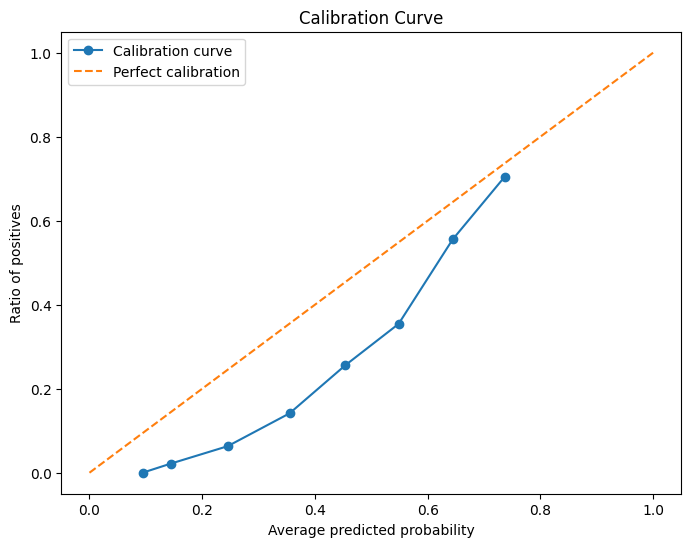

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(


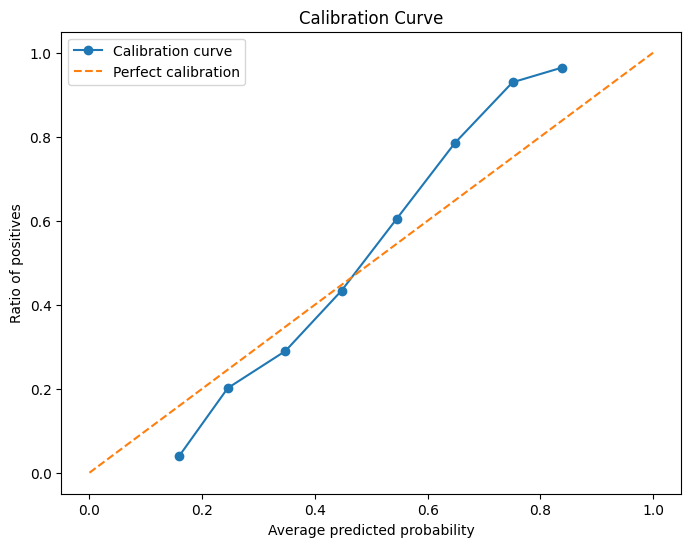

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(


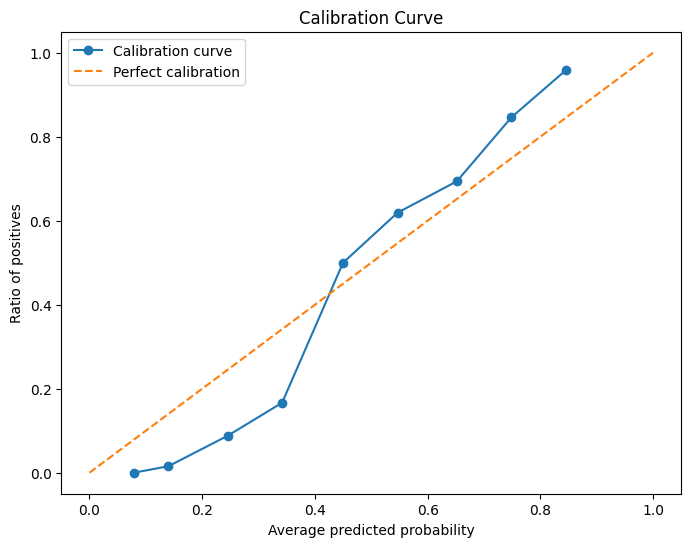

In [23]:
#calibration_curve
#彩色版 ，棄用
#需手動操作

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

#跑第二次要註解掉
# def save_predictions(predictions, filename):
#      np.save(filename, predictions)


def calibration(y_true, y_prob):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
    plt.xlabel('Average predicted probability')
    plt.ylabel('Ratio of positives')
    plt.title('Calibration Curve')
    plt.legend()
    plt.show()   

def run_calibration(local_best_model_dict, dataset_dict):
    task_name_list = list(dataset_dict.keys())
    calibration_results = {}

    for task_name in task_name_list:
        model = local_best_model_dict[task_name]['model']
        model.eval()
        X = dataset_dict[task_name].inputs.numpy()
        Y = dataset_dict[task_name].labels.unsqueeze(1).numpy()
        
        prob = model.predict_prob(X)[task_name].cpu().detach().numpy()
        preds = Y.flatten()
        
        calibration(preds, prob)  # 傳遞兩個參數

        
        # 儲存預測結果，跑第二次記得註解掉
        #save_predictions(prob, f"C:/Users/USER/M1326168/MIMIC/DNR/20250507/model_parm/{task_name}_predictions.npy")

    return calibration_results

print("Running Calibration on Test Data...")
calibration_results = run_calibration(best_model_dict, test_dataset_dict)

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Running Calibration Curve on Test Data...
圖表已儲存為 TIFF 檔案：C:/Users/USER/M1326168/MIMIC/DNR/20250507/calibration_curve.tiff


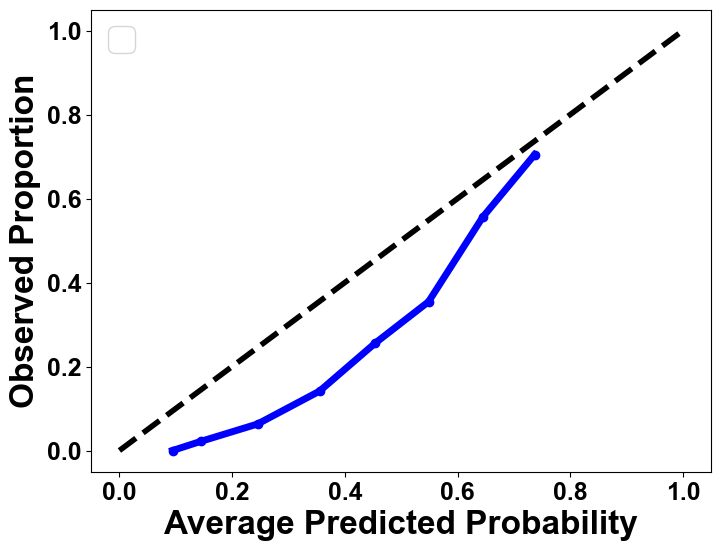

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


圖表已儲存為 TIFF 檔案：C:/Users/USER/M1326168/MIMIC/DNR/20250507/calibration_curve.tiff


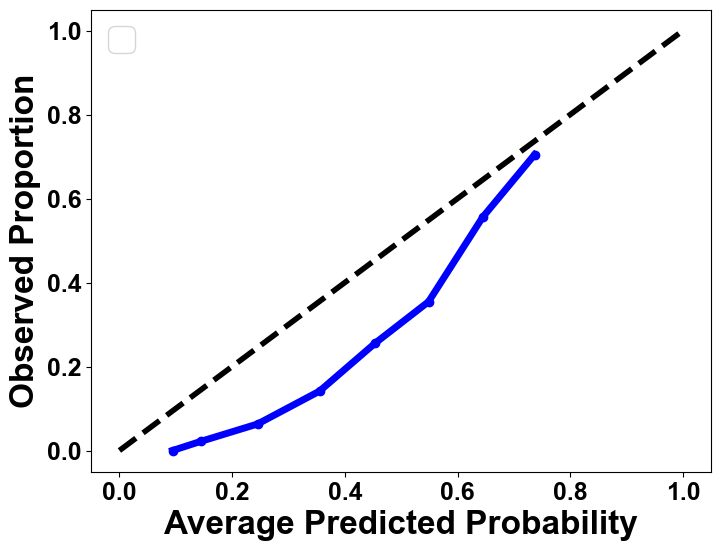

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


圖表已儲存為 TIFF 檔案：C:/Users/USER/M1326168/MIMIC/DNR/20250507/calibration_curve.tiff


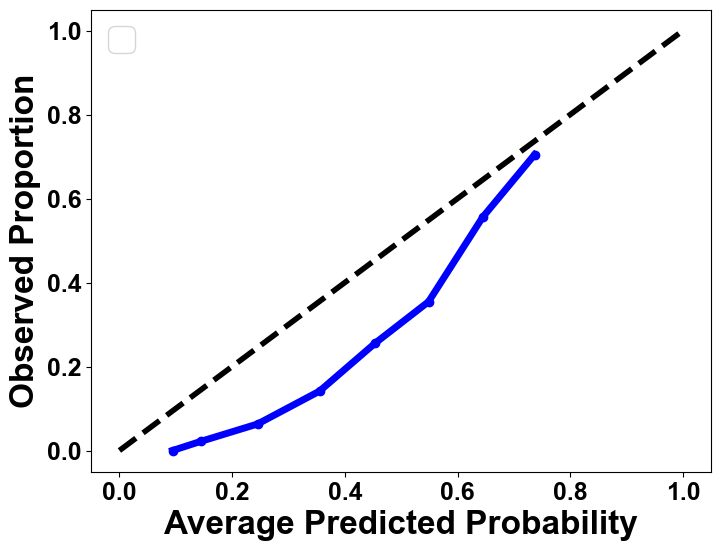

In [24]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import numpy as np

def plot_calibration_curve(y_true, y_prob, model_name, n_bins=10, save_path=None):
    """
    繪製校準曲線 (Calibration Curve)
    :param y_true: 真實標籤
    :param y_prob: 預測機率
    :param model_name: 模型名稱
    :param n_bins: 分箱數量
    :param save_path: 如果提供路徑，將圖表儲存為檔案
    """
    # 計算校準曲線
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)

    # 繪製校準曲線
    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, marker='o', color='blue', lw = 5)
    plt.plot([0, 1], [0, 1], linestyle='--', color='black', lw = 4)

    # 設定字體大小和樣式
    font_properties = {'size': 24, 'family': 'Arial', 'weight': 'bold'}
    plt.xlabel('Average Predicted Probability', fontdict=font_properties)
    plt.ylabel('Observed Proportion', fontdict=font_properties)
    #plt.title(f'Calibration Curve - {model_name}', fontdict=font_properties)
    plt.legend(loc="best", prop={'size': 24, 'family': 'Arial', 'weight': 'bold'})

    # 設定刻度字體大小
    plt.xticks(fontsize=18, fontfamily='Arial', fontweight='bold')
    plt.yticks(fontsize=18, fontfamily='Arial', fontweight='bold')

    # 儲存或顯示圖表
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    #     print(f"Calibration curve saved to {save_path}")
    # else:
    #     plt.show()
    output_path = f'C:/Users/USER/M1326168/MIMIC/DNR/20250507/calibration_curve.tiff'
    plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight')
    print(f"圖表已儲存為 TIFF 檔案：{output_path}")
    plt.show()

def run_calibration_on_tasks(local_best_model_dict, dataset_dict):
    """
    為每個任務繪製校準曲線
    :param local_best_model_dict: 包含最佳模型的字典
    :param dataset_dict: 測試數據集字典
    """
    for task_name in dataset_dict.keys():
        # model = local_best_model_dict[task_name]['model']
        model = local_best_model_dict['DNR']['model']
        model.eval()
        # X = dataset_dict[task_name].inputs.numpy()
        # Y = dataset_dict[task_name].labels.unsqueeze(1).numpy()
        X = dataset_dict['DNR'].inputs.numpy()
        Y = dataset_dict['DNR'].labels.unsqueeze(1).numpy()

        # 獲取預測機率
        # prob = model.predict_prob(X)[task_name].cpu().detach().numpy()
        prob = model.predict_prob(X)['DNR'].cpu().detach().numpy()

        # 繪製校準曲線
        plot_calibration_curve(Y.flatten(), prob.flatten(), model_name=task_name)

# 呼叫函數進行測試
print("Running Calibration Curve on Test Data...")
run_calibration_on_tasks(best_model_dict, test_dataset_dict)

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Running ROC curve on Test Data...
圖表已儲存為 TIFF 檔案：C:/Users/USER/M1326168/MIMIC/DNR/20250507/ROC_curve.tiff


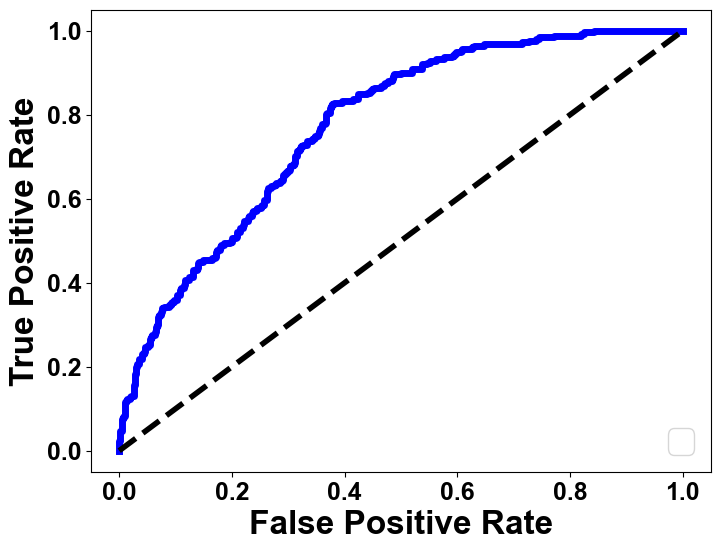

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


圖表已儲存為 TIFF 檔案：C:/Users/USER/M1326168/MIMIC/DNR/20250507/ROC_curve.tiff


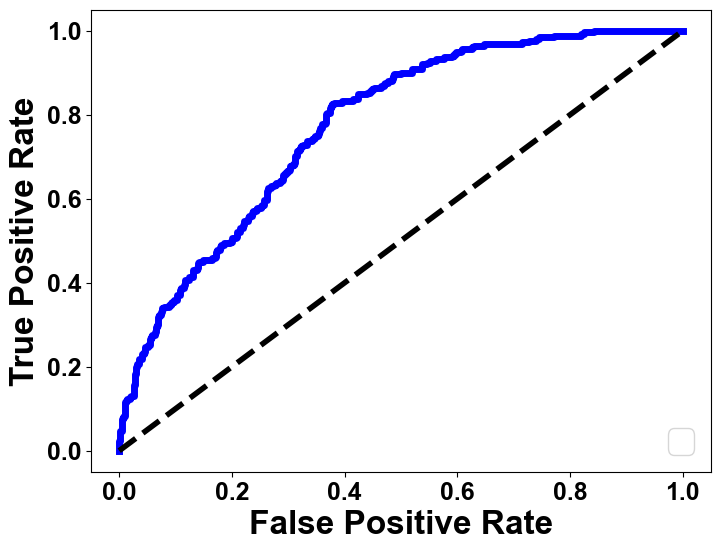

c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


圖表已儲存為 TIFF 檔案：C:/Users/USER/M1326168/MIMIC/DNR/20250507/ROC_curve.tiff


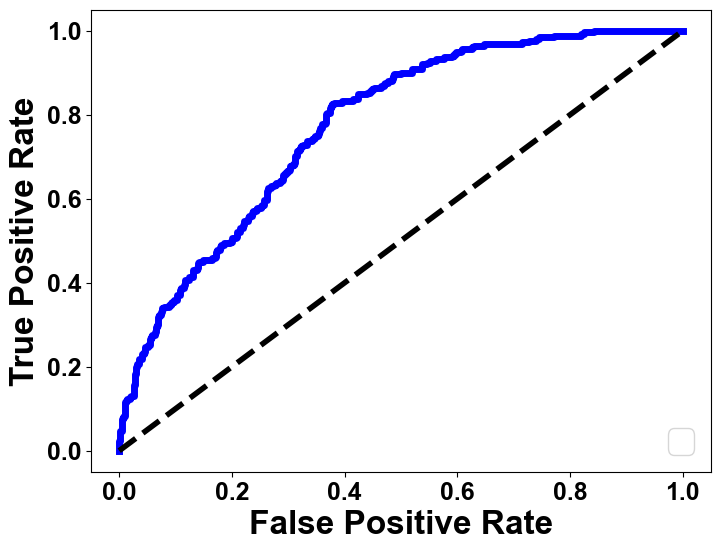

In [25]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(labels, preds, model_name, save_path=None):
    """
    繪製 ROC 曲線
    :param labels: 真實標籤
    :param preds: 預測機率
    :param model_name: 模型名稱
    :param save_path: 如果提供路徑，將圖表儲存為檔案
    """
    fpr, tpr, _ = roc_curve(labels, preds)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    # plt.plot(fpr, tpr, color='black', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    # plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Chance')
    #plt.plot(fpr, tpr, color='black', lw=2)
    plt.plot(fpr, tpr, color='blue', lw=5)

    plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=4)
    
    # 設定字體大小和樣式
    font_properties = {'size': 24, 'family': 'Arial', 'weight': 'bold'}
    plt.xlabel('False Positive Rate', fontdict=font_properties)
    plt.ylabel('True Positive Rate', fontdict=font_properties)
    #plt.title(f'ROC Curve - {model_name}', fontdict=font_properties)
    plt.legend(loc="lower right", prop={'size': 24, 'family': 'Arial', 'weight': 'bold'})
    
    # 設定刻度字體大小
    plt.xticks(fontsize=18, fontfamily='Arial', fontweight='bold')
    plt.yticks(fontsize=18, fontfamily='Arial', fontweight='bold')
    
    # # 儲存或顯示圖表
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    #     print(f"ROC curve saved to {save_path}")
    # else:
    #     plt.show()

    output_path = f'C:/Users/USER/M1326168/MIMIC/DNR/20250507/ROC_curve.tiff'
    plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight')
    print(f"圖表已儲存為 TIFF 檔案：{output_path}")
    plt.show()

def run_roc_curve_on_tasks(local_best_model_dict, dataset_dict):
    """
    為每個任務繪製 ROC 曲線
    """
    for task_name in dataset_dict.keys():
        #model = local_best_model_dict[task_name]['model']
        model = local_best_model_dict['DNR']['model']
        model.eval()
        # X = dataset_dict[task_name].inputs.numpy()
        # Y = dataset_dict[task_name].labels.unsqueeze(1).numpy()
        X = dataset_dict['DNR'].inputs.numpy()
        Y = dataset_dict['DNR'].labels.unsqueeze(1).numpy()
        
        # 獲取預測機率
        # prob = model.predict_prob(X)[task_name].cpu().detach().numpy()
        prob = model.predict_prob(X)['DNR'].cpu().detach().numpy()
        
        # 繪製 ROC 曲線
        plot_roc_curve(Y.flatten(), prob.flatten(), model_name=task_name)

# 呼叫函數進行測試
print("Running ROC curve on Test Data...")
run_roc_curve_on_tasks(best_model_dict, test_dataset_dict)

In [26]:
# ROC curve
#彩色版 ，棄用

# import numpy as np
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt

# def plot_roc_curve(labels, preds, model_name, save_path=None):
#     """
#     繪製 ROC 曲線
#     :param labels: 真實標籤
#     :param preds: 預測機率
#     :param model_name: 模型名稱
#     :param save_path: 如果提供路徑，將圖表儲存為檔案
#     """
#     fpr, tpr, _ = roc_curve(labels, preds)
#     roc_auc = auc(fpr, tpr)
    
#     plt.figure(figsize=(8, 6))
#     # plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
#     # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
#     plt.plot(fpr, tpr, color='darkorange', lw=2)
#     plt.plot([0, 1], [0, 1], color='navy', lw=2)
#     plt.xlabel('False Positive Rate')
#     plt.ylabel('True Positive Rate')
#     plt.title(f'ROC Curve - {model_name}')
#     plt.legend(loc="lower right")
    
#     if save_path:
#         plt.savefig(save_path)
#         print(f"ROC curve saved to {save_path}")
#     else:
#         plt.show()

# def run_roc_curve_on_tasks(local_best_model_dict, dataset_dict):
#     """
#     為每個任務繪製 ROC 曲線
#     """
#     for task_name in dataset_dict.keys():
#         model = local_best_model_dict[task_name]['model']
#         model.eval()
#         X = dataset_dict[task_name].inputs.numpy()
#         Y = dataset_dict[task_name].labels.unsqueeze(1).numpy()
        
#         # 獲取預測機率
#         prob = model.predict_prob(X)[task_name].cpu().detach().numpy()
        
#         # 繪製 ROC 曲線
#         plot_roc_curve(Y.flatten(), prob.flatten(), model_name=task_name)

# print("Running ROC curve on Test Data...")
# run_roc_curve_on_tasks(best_model_dict, test_dataset_dict)

In [27]:
#delong test

import numpy as np
import scipy.stats as st

def load_predictions(filename):
    return np.load(filename)

def delong_test(preds1, preds2, labels):
    def _auc(X, Y):
        return 1 / (len(X) * len(Y)) * sum([_kernel(x, y) for x in X for y in Y])

    def _kernel(x, y):
        return 0.5 if x == y else int(y < x)

    def _structural_components(X, Y):
        V10 = [1 / len(Y) * sum([_kernel(x, y) for y in Y]) for x in X]
        V01 = [1 / len(X) * sum([_kernel(x, y) for x in X]) for y in Y]
        return V10, V01

    def _get_S_entry(V_A, V_B, auc_A, auc_B):
        return 1 / (len(V_A) - 1) * sum([(a - auc_A) * (b - auc_B) for a, b in zip(V_A, V_B)])
    
    X_A = [p for p, a in zip(preds1, labels) if a == 1]
    Y_A = [p for p, a in zip(preds1, labels) if a == 0]
    X_B = [p for p, a in zip(preds2, labels) if a == 1]
    Y_B = [p for p, a in zip(preds2, labels) if a == 0]
    
    auc_A = _auc(X_A, Y_A)
    auc_B = _auc(X_B, Y_B)

    V_A10, V_A01 = _structural_components(X_A, Y_A)
    V_B10, V_B01 = _structural_components(X_B, Y_B)

    var_A = (_get_S_entry(V_A10, V_A10, auc_A, auc_A) / len(V_A10) +
             _get_S_entry(V_A01, V_A01, auc_A, auc_A) / len(V_A01))
    var_B = (_get_S_entry(V_B10, V_B10, auc_B, auc_B) / len(V_B10) +
             _get_S_entry(V_B01, V_B01, auc_B, auc_B) / len(V_B01))
    covar_AB = (_get_S_entry(V_A10, V_B10, auc_A, auc_B) / len(V_A10) +
                _get_S_entry(V_A01, V_B01, auc_A, auc_B) / len(V_A01))
    
    z = (auc_A - auc_B) / ((var_A + var_B - 2 * covar_AB)**0.5 + 1e-8)
    p = st.norm.sf(abs(z)) * 2
    
    return auc_A, auc_B, z, p

def run_delong_test_on_tasks(local_best_model_dict, dataset_dict, task_name_list1, task_name_list2):
    preds1 = load_predictions('C:/Users/USER/M1326168/MIMIC/DNR/20250507/model_parm/DNR_predictions.npy')
    preds2 = []
    labels = None
    
    for task_name in task_name_list2:
        model = local_best_model_dict[task_name]['model']
        model.eval()
        X = dataset_dict[task_name].inputs.numpy()
        Y = dataset_dict[task_name].labels.unsqueeze(1).numpy()
        
        prob = model.predict_prob(X)[task_name].cpu().detach().numpy()
        preds2.extend(prob.flatten())
        if labels is None:
            labels = Y.flatten()
    
    auc_A, auc_B, z, p = delong_test(preds1, preds2, labels)
    
    delong_results = {'auc_model1': auc_A, 'auc_model2': auc_B, 'z_score': z, 'p_value': p}
    print(f"AUC Model of single-task learning: {auc_A:.5f}")
    #print(f"AUC Model of 3 task: {auc_A:.5f}")
    #print(f"AUC Model of multi-task learning: {auc_B:.5f}")
    print(f"AUC Model of 3 task learning: {auc_B:.5f}")
    #print(f"AUC Model of 5 task learning: {auc_B:.5f}")
    print(f"z-score: {z:.5f}")
    print(f"p-value: {p:.5f}")
    
    return delong_results

print("Running DeLong Test on Test Data...")
task_name_list1 = ['DNR']
#task_name_list1 = ['DNR','dod_30day','Vasopressor']
#task_name_list2 = ['DNR']
#task_name_list2 = ['DNR','dod_30day','Vasopressor','InvasiveVent','dialysis']
task_name_list2 = ['DNR','dod_30day','Vasopressor']
delong_results = run_delong_test_on_tasks(best_model_dict, test_dataset_dict, task_name_list1, task_name_list2)

Running DeLong Test on Test Data...


c:\Users\USER\anaconda3\lib\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
C:\Users\USER\AppData\Local\Temp\ipykernel_15872\2176257931.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 0.5 if x == y else int(y < x)


AUC Model of single-task learning: 0.80135
AUC Model of 3 task learning: 0.77457
z-score: 4.27899
p-value: 0.00002


In [28]:
from sklearn.metrics import confusion_matrix


def calculate_net_benefit_model(thresh_group, y_pred_score, y_label):
    net_benefit_model = np.array([])
    for thresh in thresh_group:
        y_pred_label = y_pred_score > thresh
        tn, fp, fn, tp = confusion_matrix(y_label, y_pred_label).ravel()
        n = len(y_label)
        net_benefit = (tp / n) - (fp / n) * (thresh / (1 - thresh))
        net_benefit_model = np.append(net_benefit_model, net_benefit)
    return net_benefit_model


def calculate_net_benefit_all(thresh_group, y_label):
    net_benefit_all = np.array([])
    tn, fp, fn, tp = confusion_matrix(y_label, y_label).ravel()
    total = tp + tn
    for thresh in thresh_group:
        net_benefit = (tp / total) - (tn / total) * (thresh / (1 - thresh))
        net_benefit_all = np.append(net_benefit_all, net_benefit)
    return net_benefit_all
def plot_DCA(ax, thresh_group, net_benefit_model, net_benefit_all , model_id,model_name_list):
    
    choose_colar = 'darkorange'
    if model_id == 1:
        choose_colar = 'blue'
    elif model_id == 2:
        choose_colar = 'green'
    else:
        choose_colar = 'red'
    
    choose_colar = 'black'
    #Plot

    #ax.plot(thresh_group, net_benefit_model, color = choose_colar)
    ax.plot(thresh_group, net_benefit_model, color = 'blue',lw = 5)

    #ax.plot(thresh_group, net_benefit_model, color = choose_colar, label = f'{model_name_list[model_id]}')
    
    if model_id == 1:
        #ax.plot(thresh_group, net_benefit_all, color = 'black',label = 'Treat all')
        #ax.plot((0, 1), (0, 0), color = 'black', linestyle = ':', label = 'Treat none')
        ax.plot(thresh_group, net_benefit_all, color = 'black',lw = 5)
        ax.plot((0, 1), (0, 0), color = 'black', linestyle = ':',lw = 5)
    ax.plot(thresh_group, net_benefit_all, color = 'black',lw = 4)
    ax.plot((0, 1), (0, 0), color = 'black', linestyle = ':',lw = 4)
    
    #Fill，显示出模型较于treat all和treat none好的部分
    y2 = np.maximum(net_benefit_all, 0)
    y1 = np.maximum(net_benefit_model, y2)
    ax.fill_between(thresh_group, y1, y2, color = 'black', alpha = 0.2)
    
    font_properties = {'size': 24,  'family': 'Arial', 'fontweight':'bold'}
    plt.xticks(fontproperties='Arial', **font_properties)
    plt.yticks(fontproperties='Arial', **font_properties)
    
    #Figure Configuration， 美化一下细节
    ax.set_xlim(0,1)
    ax.set_ylim(net_benefit_model.min() - 0.15, net_benefit_model.max() + 0.15)#adjustify the y axis limitation
    ax.set_xlabel(
        xlabel = 'Threshold Probability', 
        fontdict= {'fontfamily':'Arial', 'fontsize': 24, 'fontweight':'bold'}
        )
    ax.set_ylabel(
        ylabel = 'Net Benefit', 
        fontdict= {'fontfamily':'Arial', 'fontsize': 24, 'fontweight':'bold'}
        )
    
    #ax.grid('major')
    ax.spines['right'].set_color((0.8, 0.8, 0.8))
    ax.spines['top'].set_color((0.8, 0.8, 0.8))
    #ax.legend(loc = 'upper right')
    plt.legend().set_visible(False)

    return ax

Model output keys: dict_keys(['DNR', 'dod_30day', 'Vasopressor'])


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/USER/M1326168/MIMIC/DNR/20250618/decision_curve.tiff'

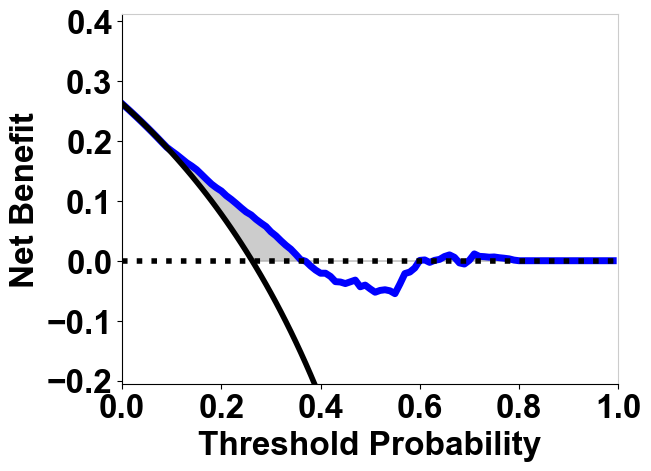

In [29]:
#decision_curve
def decision_curve(model_list, model_name_list, x, y, task_name):
    """
    繪製決策曲線
    """
    if torch.is_tensor(x):
        x = x.numpy()
        y = y.numpy()
        
    assert len(model_list) == len(model_name_list)
    fig, ax = plt.subplots()
    for i in range(len(model_list)):
        model = model_list[i]
        model.eval()
        if torch.is_tensor(x):
            x = x.cpu().numpy()
        x = torch.from_numpy(x).float().to(device)
        y_label = y

        # 模型預測
        out = model(x)
        if isinstance(out, dict):  # 如果輸出是字典
            print(f"Model output keys: {out.keys()}")  # 打印字典的鍵
            # 修改這裡，根據實際鍵名稱提取值
            y_pred_score = out.get('DNR', None)  # 使用 .get() 避免 KeyError
            if y_pred_score is None:
                raise KeyError("The key 'logits' was not found in the model output. Please check the output keys.")
        else:  # 如果輸出是張量
            y_pred_score = out

        y_pred_score = y_pred_score.float().cpu().detach().numpy()
        y_pred = (y_pred_score > 0.5).astype(int)
        
        # 計算 Net Benefit
        thresh_group = np.arange(0, 1, 0.01)
        net_benefit_model = calculate_net_benefit_model(thresh_group, y_pred_score, y_label)
        net_benefit_all = calculate_net_benefit_all(thresh_group, y_label)

        # 繪製決策曲線
        plot_DCA(ax, thresh_group, net_benefit_model, net_benefit_all, i, model_name_list)

    # plt.show()
    output_path = f'C:/Users/USER/M1326168/MIMIC/DNR/20250618/decision_curve.tiff'
    plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight')
    print(f"圖表已儲存為 TIFF 檔案：{output_path}")
    plt.show()

# 呼叫 decision_curve
for task_name in task_name_list2:
    model = best_model_dict[task_name]['model']
    model.eval()
    X = test_dataset_dict[task_name].inputs.numpy()
    Y = test_dataset_dict[task_name].labels.unsqueeze(1).numpy()
    
    
    # 呼叫 decision_curve，傳入正確的參數
    decision_curve(
        model_list=[model],  # 單一模型列表
        #model_name_list=[task_name],  # 單一模型名稱列表
        model_name_list=['DNR'],  # 單一模型名稱列表
        x=X,  # 測試資料的輸入
        y=Y,  # 測試資料的標籤
        task_name=task_name  # 任務名稱
    )

In [ ]:
#棄用
# #decision_curve
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.metrics import precision_recall_curve

# def decision_curve_analysis(y_true, y_prob, thresholds=np.arange(0.0, 1.01, 0.01)):
#     net_benefit = []
#     for threshold in thresholds:
#         tp = np.sum((y_prob >= threshold) & (y_true == 1))
#         fp = np.sum((y_prob >= threshold) & (y_true == 0))
#         fn = np.sum((y_prob < threshold) & (y_true == 1))
#         tn = np.sum((y_prob < threshold) & (y_true == 0))       
#         n = len(y_true)
#         p = np.sum(y_true)
#         nb = (tp / n) - (fp / n) * (threshold / (1 - threshold))
#         net_benefit.append(nb)
    
#     return thresholds, net_benefit

# def plot_decision_curve(y_true, y_prob, model_name):
#     thresholds, net_benefit = decision_curve_analysis(y_true, y_prob)
    
#     plt.figure(figsize=(10, 6))
#     plt.plot(thresholds, net_benefit, label=f'{model_name} Decision Curve')
#     plt.plot(thresholds, thresholds * (np.sum(y_true) / len(y_true)), linestyle='--', label='Treat All')
#     plt.plot(thresholds, np.zeros_like(thresholds), linestyle='--', label='Treat None')
#     plt.xlabel('Threshold Probability')
#     plt.ylabel('Net Benefit')
#     plt.title('Decision Curve Analysis')
#     plt.legend()
#     plt.show()

# # 繪製決策曲線
# for task_name in task_name_list2:
#     model = best_model_dict[task_name]['model']
#     model.eval()
#     X = test_dataset_dict[task_name].inputs.numpy()
#     Y = test_dataset_dict[task_name].labels.unsqueeze(1).numpy()
    
#     prob = model.predict_prob(X)[task_name].cpu().detach().numpy()
#     plot_decision_curve(Y.flatten(), prob.flatten(), task_name)

In [30]:
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from datetime import datetime

def group_result(df):
    # 若沒有 ppv 欄位則用 pre 補上
    if 'ppv' not in df.columns and 'pre' in df.columns:
        df['ppv'] = df['pre']
    if 'npv' not in df.columns:
        df['npv'] = 0.0  # 若舊資料沒有 NPV，補 0
    agg_columns = {
        'acc': ['mean', 'std'],
        'pre': ['mean', 'std'],
        'ppv': ['mean', 'std'],
        'npv': ['mean', 'std'],  
        'f1': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'auroc': ['mean', 'std'],
        'auprc': ['mean', 'std'],
        'brier_score': ['mean', 'std']
    }
    df_group = df.groupby('task').agg(agg_columns)
    df_group.columns = [f"{col[0]}_{col[1]}" for col in df_group.columns]
    for metric in ['acc', 'pre', 'ppv', 'npv', 'f1', 'recall', 'auroc', 'auprc', 'brier_score']:
        df_group[f"{metric}_combined"] = df_group.apply(
            lambda row: f"{row[f'{metric}_mean']:.4f} ± {row[f'{metric}_std']:.4f}", axis=1
        )
    df_result = df_group[[f"{metric}_combined" for metric in ['acc', 'pre', 'ppv', 'npv', 'f1', 'recall', 'auroc', 'auprc','brier_score']]]
    df_result.reset_index(inplace=True)
    df_result.columns = ['task','acc', 'pre', 'ppv', 'npv', 'f1', 'recall', 'auroc', 'auprc','brier_score']
    return df_result


def save_to_xlsx(df_save,file_name = 'output'):
    wb = Workbook()
    ws = wb.active
    for r_idx, row in enumerate(dataframe_to_rows(df_save, index=False, header=True), 1):
        for c_idx, value in enumerate(row, 1):
            ws.cell(row=r_idx, column=c_idx, value=value)
    #wb.save(f'./model_parm/{file_name}.xlsx')model.
    wb.save(f'C:/Users/USER/M1326168/MIMIC/DNR/transformer_test/model_parm/{file_name}.xlsx')

current_time = datetime.now().strftime('%Y%m%d_%H%M%S')
df_grade_group = group_result(df_grade)

In [31]:
df_grade_group


,task,acc,pre,ppv,npv,f1,recall,auroc,auprc,brier_score
0,DNR,0.6855 ± 0.0248,0.4412 ± 0.0235,0.4412 ± 0.0235,0.8709 ± 0.0224,0.5417 ± 0.0154,0.7120 ± 0.0827,0.7814 ± 0.0074,0.5486 ± 0.0166,0.1942 ± 0.0086
1,Vasopressor,0.8980 ± 0.0050,0.8288 ± 0.0188,0.8288 ± 0.0188,0.9212 ± 0.0129,0.7991 ± 0.0156,0.7735 ± 0.0419,0.9527 ± 0.0028,0.8806 ± 0.0088,0.0865 ± 0.0028
2,dod_30day,0.8074 ± 0.0070,0.8304 ± 0.0209,0.8304 ± 0.0209,0.7806 ± 0.0288,0.8310 ± 0.0096,0.8331 ± 0.0361,0.8924 ± 0.0025,0.9160 ± 0.0032,0.1488 ± 0.0044


In [ ]:
save_to_xlsx(df_grade_group)

In [32]:
#df_columns = pd.read_csv("./data/sample/full_feature_name.csv")

#df_columns = pd.read_csv("C:/Users/USER/M1326168/MIMIC/DNR/20250219/data/sample/full_feature_name.csv")
df_columns = pd.read_csv("C:/Users/USER/M1326168/MIMIC/DNR/transformer_test/data/sample/full_feature_name.csv")
temperal = 0
feature_list = df_columns.columns.tolist()
for i in range(len(feature_list)):
    print(feature_list[i])
    if df_columns.columns[i] == 'gender':
        temperal = i

SaO2
Heart Rate
Systemic Systolic
Systemic Diastolic
Systemic Mean
Consecutive_Vasopressor_Over3
Consecutive_Vasopressor_Over7
dialysis_over3
dialysis_over7
ICU_Class_1
ICU_Class_2
ICU_Class_3
Consecutive_avg_FiO2_Over50
Consecutive_avg_FiO2_Over60
Full_code_interval
Strength Arm
Strength Leg
dialysis_acc
dialysis_since_last_event
FiO2
Minute Ventilation
Mean Airway Pressure
Peak Airway Pressure
PEEP
Plateau
Tidal Volume
Respiratory Rate
RASS
Platelets x1000
WBC x1000
Hgb
PO2
PaCO2
Glucose
BUN
pH
Sodium
Potassium
Magnesium
Calcium
Chloride
creatinine
HCO3
Phosphate
PT-INR
Sedation
PPI
Pain control
total
Fluid_intake_value
Nutrition_Enteral_value
Urine_value
Aspergillus
Candida
Abdomen
Blood
Respiratory tract
Skin and soft tissue
Urinary tract
Others
Anxiety
Assess for anxiety, depression, or delirium which may contribut
Asystole
Blood Transfusion
Consult to pastoral care, social services, palliative care, psy
Early mobilization
Encourage family to participate in care
Encourage patient 

In [33]:
print(f'時序特徵:{temperal}  靜態特徵:{len(df_columns.columns)-temperal}')

時序特徵:125  靜態特徵:145


In [ ]:
# import shap
# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# # ==============================================================================
# # 1. 定義 SHAP 分析所需的工具類別與函數
# # ==============================================================================

# class ModelWrapper(torch.nn.Module):
#     """
#     包裝器：將模型的字典輸出轉換為單一 Tensor，以便 SHAP 套件讀取。
#     """
#     def __init__(self, model, task_name):
#         super(ModelWrapper, self).__init__()
#         self.model = model
#         self.task_name = task_name
        
#     def forward(self, x):
#         # 讓模型輸出特定任務的 Logits (或是 Probability)
#         out = self.model(x)
#         if isinstance(out, dict):
#             return out[self.task_name]
#         return out

# def run_shap_analysis(model, train_loader, test_loader, task_name, feature_names, device):
#     """
#     計算 SHAP 值並繪圖的主函數
#     """
#     print(f"\n[{task_name}] 正在計算 SHAP 值...")
    
#     # 1. 準備背景數據 (Background Data) - 用於建立基準
#     try:
#         batch_data = next(iter(train_loader))[0]
#         background_data = batch_data[:100].to(device) # 取 100 筆訓練資料當背景
#     except StopIteration:
#         print("Error: Train loader is empty.")
#         return

#     # 2. 準備解釋數據 (Test Data) - 我們要解釋這些資料的預測結果
#     try:
#         test_batch = next(iter(test_loader))[0]
#         to_explain_data = test_batch[:50].to(device) # 取 50 筆測試資料來解釋
#     except StopIteration:
#         print("Error: Test loader is empty.")
#         return

#     # 3. 包裝模型
#     wrapped_model = ModelWrapper(model, task_name).to(device)
#     wrapped_model.eval()

#     # 4. 初始化解釋器 (使用 GradientExplainer)
#     # 注意：LSTM/RNN 在計算梯度時可能會與 CUDNN 衝突，稍後會用 context manager 處理
#     explainer = shap.GradientExplainer(wrapped_model, background_data)
    
#     # 5. 計算 SHAP 值
#     # shap_values 的形狀通常是 [Batch, Window, Features]
#     shap_values = explainer.shap_values(to_explain_data)
    
#     # 處理 list 輸出 (有些版本會回傳 list of tensors)
#     if isinstance(shap_values, list):
#         shap_values = shap_values[0]
        
#     # 6. 維度處理: [Batch, Window, Features] -> [Batch, Features]
#     # 我們將時間維度 (Window=3) 平均，代表該特徵在「這段期間內」的整體重要性
#     if len(shap_values.shape) == 3:
#         # 對時間軸取平均
#         shap_values_flat = np.mean(shap_values, axis=1) 
#         to_explain_data_flat = to_explain_data.mean(dim=1).cpu().detach().numpy()
#     else:
#         shap_values_flat = shap_values
#         to_explain_data_flat = to_explain_data.cpu().detach().numpy()

#     # 7. 繪製 Summary Plot (蜂群圖)
#     print(f"[{task_name}] 繪製 Summary Plot (Top 20 特徵)...")
#     plt.figure(figsize=(10, 6))
#     plt.title(f"SHAP Summary Plot - {task_name}", fontsize=14)
#     shap.summary_plot(
#         shap_values_flat, 
#         to_explain_data_flat, 
#         feature_names=feature_names, 
#         max_display=20, 
#         show=False
#     )
#     plt.show()

#     # 8. 繪製 Bar Plot (重要性排行)
#     plt.figure(figsize=(10, 6))
#     plt.title(f"Feature Importance Bar Plot - {task_name}", fontsize=14)
#     shap.summary_plot(
#         shap_values_flat, 
#         to_explain_data_flat, 
#         feature_names=feature_names, 
#         plot_type="bar", 
#         max_display=20, 
#         show=False
#     )
#     plt.show()

# # ==============================================================================
# # 2. 執行區塊 (請確保模型已訓練完成)
# # ==============================================================================

# # 檢查變數是否存在 (避免未訓練就執行報錯)
# if 'stl_model_dict' in globals() and 'train_loader_dict' in globals():
    
#     # 暫時關閉 CUDNN (避免 RNN Backward Error)
#     with torch.backends.cudnn.flags(enabled=False):
        
#         for task_name in task_name_list:
#             if task_name in stl_model_dict:
                
#                 # 取得該任務的模型
#                 target_model = stl_model_dict[task_name]
                
#                 # 執行分析
#                 try:
#                     run_shap_analysis(
#                         model=target_model,
#                         train_loader=train_loader_dict[task_name],
#                         test_loader=test_dataset_dict[task_name] if isinstance(test_dataset_dict[task_name], torch.utils.data.DataLoader) else DataLoader(test_dataset_dict[task_name], batch_size=256), # 確保是 Loader
#                         task_name=task_name,
#                         feature_names=feature_name_list, # 確保這是您的特徵名稱列表
#                         device=device
#                     )
#                 except Exception as e:
#                     print(f"[{task_name}] SHAP 分析發生錯誤: {e}")
#                     import traceback
#                     traceback.print_exc()
#             else:
#                 print(f"警告: 找不到任務 {task_name} 的模型。")

# else:
#     print("錯誤: 找不到 stl_model_dict 或 loader。請先執行 'train_and_test_model' 完成訓練。")


[DNR] 正在計算 SHAP 值 (Flatten Mode)...
特徵處理完成: 原始 271 -> 展開後 311


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

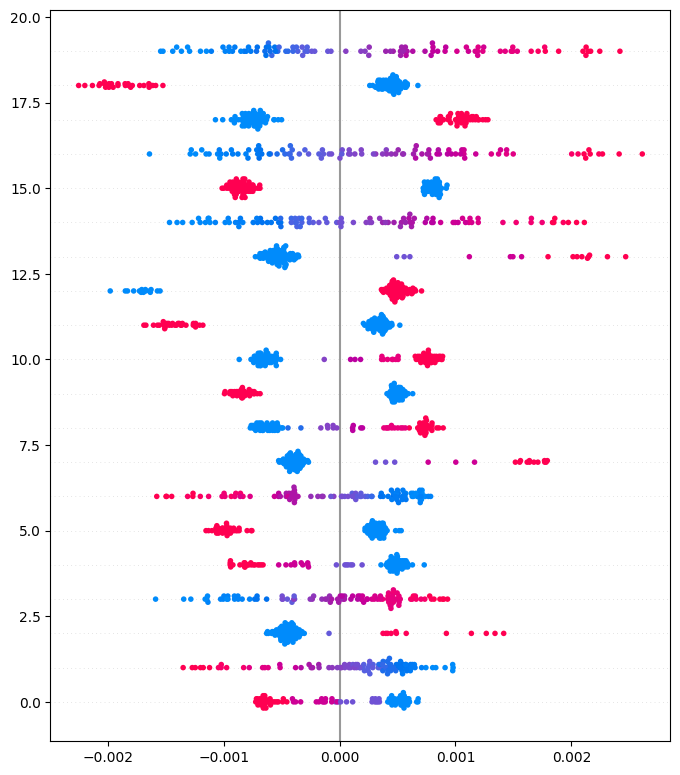

In [34]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ==============================================================================
# 1. 定義輔助類別 (ModelWrapper)
# ==============================================================================
class ModelWrapper(torch.nn.Module):
    def __init__(self, model, task_name):
        super(ModelWrapper, self).__init__()
        self.model = model
        self.task_name = task_name
        
    def forward(self, x):
        out = self.model(x)
        if isinstance(out, dict):
            return out[self.task_name]
        return out

# ==============================================================================
# 2. 定義核心分析函數 (包含 Flatten 與 Static 平均邏輯)
# ==============================================================================
def run_shap_flattened(model, train_loader, test_loader, task_name, feature_names, n_temporal, device):
    """
    計算 SHAP 並依照 (時序展開 + 靜態平均) 的邏輯處理數據，最後繪圖。
    """
    print(f"\n[{task_name}] 正在計算 SHAP 值 (Flatten Mode)...")
    
    # 1. 準備數據
    try:
        bg_data = next(iter(train_loader))[0][:100].to(device)
        test_data = next(iter(test_loader))[0][:100].to(device)
    except Exception as e:
        print(f"Dataloader Error: {e}")
        return

    # 2. 計算原始 SHAP (Output: [Batch, 3, 271])
    wrapped_model = ModelWrapper(model, task_name).to(device)
    wrapped_model.eval()
    explainer = shap.GradientExplainer(wrapped_model, bg_data)
    shap_values = explainer.shap_values(test_data)
    if isinstance(shap_values, list): shap_values = shap_values[0]
    
    # 轉為 Numpy
    shap_val_np = shap_values if isinstance(shap_values, np.ndarray) else shap_values
    data_np = test_data.cpu().detach().numpy()

    # ==========================================================================
    # 3. 關鍵修正：數據重塑 (Reshape)
    # 邏輯：前 n_temporal 個特徵展開 (D1..D3)，後面的靜態特徵取平均
    # ==========================================================================
    seq_len = shap_val_np.shape[1] # 應該是 3
    
    # A. 處理時序特徵 (0 ~ n_temporal-1) -> 展開
    # 取出 [Batch, 3, n_temporal] ->轉置-> [Batch, n_temporal, 3] -> 攤平 -> [Batch, n_temporal*3]
    shap_temporal = shap_val_np[:, :, :n_temporal].transpose(0, 2, 1).reshape(shap_val_np.shape[0], -1)
    data_temporal = data_np[:, :, :n_temporal].transpose(0, 2, 1).reshape(data_np.shape[0], -1)
    
    # 產生對應名稱 (e.g., HR_D1, HR_D2, HR_D3)
    names_temporal = []
    for i in range(n_temporal):
        for d in range(seq_len):
            names_temporal.append(f"{feature_names[i]}_D{d+1}")

    # B. 處理靜態特徵 (n_temporal ~ end) -> 平均
    # 取出 [Batch, 3, n_static] -> 平均 -> [Batch, n_static]
    if shap_val_np.shape[2] > n_temporal:
        shap_static = np.mean(shap_val_np[:, :, n_temporal:], axis=1)
        data_static = np.mean(data_np[:, :, n_temporal:], axis=1)
        names_static = feature_names[n_temporal:]
    else:
        shap_static, data_static, names_static = np.empty((shap_val_np.shape[0], 0)), np.empty((data_np.shape[0], 0)), []

    # C. 合併 (Concatenate)
    shap_final = np.hstack([shap_temporal, shap_static])
    data_final = np.hstack([data_temporal, data_static])
    names_final = names_temporal + names_static

    print(f"特徵處理完成: 原始 {len(feature_names)} -> 展開後 {len(names_final)}")

    # 4. 繪圖
    plt.figure(figsize=(12, 10))
    shap.summary_plot(
        shap_final, 
        data_final, 
        feature_names=names_final,
        plot_type="dot", 
        max_display=20,
        show=False
    )
    plt.title(f"SHAP Summary Plot ({task_name})", fontsize=16)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. 執行區塊
# ==============================================================================

# 設定時序特徵數量 (請確認這與您的資料一致，通常是 126)
#N_TEMPORAL = 126 

if 'stl_model_dict' in globals():
    with torch.backends.cudnn.flags(enabled=False):
        for task_name in task_name_list:
            if task_name in stl_model_dict:
                run_shap_flattened(
                    model=stl_model_dict[task_name],
                    train_loader=train_loader_dict[task_name],
                    test_loader=test_dataset_dict[task_name] if isinstance(test_dataset_dict[task_name], DataLoader) else DataLoader(test_dataset_dict[task_name], batch_size=256),
                    task_name=task_name,
                    feature_names=feature_name_list, # 原始 271 個名稱
                    n_temporal=20,           # 指定前幾個是時序特徵
                    device=device
                )
else:
    print("錯誤：找不到 stl_model_dict，請先執行 'train_and_test_model'。")

Processing task: DNR...
Task DNR Done.
Processing task: dod_30day...
Task dod_30day Done.
Processing task: Vasopressor...
Task Vasopressor Done.
SHAP 計算完成！

[DNR] Summary Plot:


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

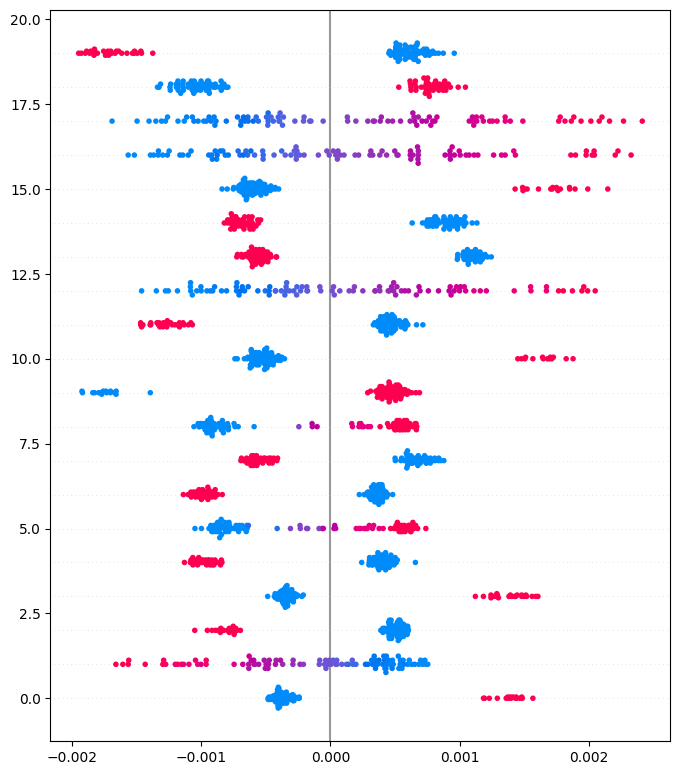

In [35]:
import shap
import torch
import numpy as np

# ==============================================================================
# 1. 定義必要的類別與函數
# ==============================================================================

class ModelWrapper(torch.nn.Module):
    """將模型包裝起來，確保只輸出單一任務的 Tensor"""
    def __init__(self, model, task_name):
        super(ModelWrapper, self).__init__()
        self.model = model
        self.task_name = task_name
        
    def forward(self, x):
        out = self.model(x)
        if isinstance(out, dict):
            return out[self.task_name]
        return out

def get_model_shap(model, data_X_train, data_X_test, data_X_test_original, feature_name_list, task_name, use_mini_sample=True, n_sample=100, n_temporal=126, n_static=145):
    """
    計算 SHAP 值並將 3D 資料 (Time Series) 轉換為 2D (Flatten) 格式以利繪圖。
    """
    device = next(model.parameters()).device
    
    # 1. 準備數據 (轉為 Tensor)
    # 背景數據 (Background) - 用於計算基準值
    bg_data = torch.from_numpy(data_X_train[:100]).float().to(device)
    # 解釋數據 (To Explain) - 用於計算 SHAP
    test_data_tensor = torch.from_numpy(data_X_test[:n_sample]).float().to(device)
    # 原始數據 (Original Scale) - 用於繪圖顯示數值大小
    test_data_original = data_X_test_original[:n_sample]

    # 2. 初始化解釋器
    wrapped_model = ModelWrapper(model, task_name).to(device)
    wrapped_model.eval()
    explainer = shap.GradientExplainer(wrapped_model, bg_data)
    
    # 3. 計算 SHAP 值 [Batch, Seq_Len, Features]
    shap_values = explainer.shap_values(test_data_tensor)
    if isinstance(shap_values, list): 
        shap_values = shap_values[0]
        
    # 轉為 Numpy
    shap_val_np = shap_values if isinstance(shap_values, np.ndarray) else shap_values

    # ==========================================================================
    # 4. 關鍵修正：數據重塑 (Reshape / Flatten)
    # 目標：將 [Batch, 3, 271] 攤平成二維，且時序特徵要展開 (D1, D2, D3)
    # ==========================================================================
    batch_size, seq_len, total_dim = shap_val_np.shape
    
    # --- A. 處理時序特徵 (0 ~ n_temporal) -> 展開 ---
    # Transpose [B, 3, T] -> [B, T, 3] -> Reshape [B, T*3]
    # 這樣排列順序會是: Feat1_D1, Feat1_D2, Feat1_D3, Feat2_D1...
    shap_temp = shap_val_np[:, :, :n_temporal].transpose(0, 2, 1).reshape(batch_size, -1)
    data_temp = test_data_original[:, :, :n_temporal].transpose(0, 2, 1).reshape(batch_size, -1)
    
    # 產生對應的名稱
    full_feature_names = []
    for i in range(n_temporal):
        for d in range(seq_len):
            full_feature_names.append(f"{feature_name_list[i]}_D{d+1}")
            
    # --- B. 處理靜態特徵 (n_temporal ~ end) -> 取平均 ---
    # 因為靜態特徵在 3 天內數值都一樣，取平均即可
    if total_dim > n_temporal:
        shap_static = np.mean(shap_val_np[:, :, n_temporal:], axis=1)
        data_static = np.mean(test_data_original[:, :, n_temporal:], axis=1)
        # 加入名稱
        full_feature_names.extend(feature_name_list[n_temporal:])
    else:
        shap_static = np.empty((batch_size, 0))
        data_static = np.empty((batch_size, 0))

    # --- C. 合併 ---
    shap_value_flatten = np.hstack([shap_temp, shap_static])
    shap_data_flatten = np.hstack([data_temp, data_static])

    # 5. 計算特徵重要性 (Feature Importance) 並排序
    # 取絕對值平均作為重要性指標
    feature_importance_vals = np.abs(shap_value_flatten).mean(0)
    
    # 排序索引 (大到小)
    sorted_idx = np.argsort(feature_importance_vals)[::-1]
    
    # 產生排序後的名稱列表與字典
    feature_important = [full_feature_names[i] for i in sorted_idx]
    feature_important_dict = {full_feature_names[i]: feature_importance_vals[i] for i in range(len(full_feature_names))}

    return feature_important, shap_value_flatten, shap_data_flatten, feature_important_dict

# ==============================================================================
# 2. 執行計算 (仿照您的迴圈格式)
# ==============================================================================

# 參數設定 (請確保與您訓練時一致)
n_temporal = 126
n_static = 145
seq_day = 3
sum_shap_value = np.zeros((0, seq_day * n_temporal + n_static))
sum_shap_data = np.zeros((0, seq_day * n_temporal + n_static))
shap_dict = {}

# 暫時關閉 CUDNN 以避免 LSTM 報錯
with torch.backends.cudnn.flags(enabled=False):
    
    for task_name in task_name_list:
        print(f"Processing task: {task_name}...")
        
        # 確保模型存在
        if task_name not in stl_model_dict:
            print(f"Warning: Model for {task_name} not found.")
            continue
            
        shap_dict[task_name] = {}
        
        # 呼叫修正後的 get_model_shap
        feature_important, shap_value_flatten, shap_data_flatten, feature_important_dict = get_model_shap(
            model = stl_model_dict[task_name],
            data_X_train = train_dataset_dict[task_name].inputs.numpy(),
            data_X_test = test_dataset_dict[task_name].inputs.numpy(),
            data_X_test_original = test_dataset_dict[task_name].inputs_original.numpy(),
            feature_name_list = feature_name_list,
            task_name = task_name,
            use_mini_sample = True, # 設為 True 速度較快
            n_sample = 100,         # 取 100 筆樣本解釋
            n_temporal = n_temporal,
            n_static = n_static
        )

        # 填入結果
        shap_dict[task_name]['feature_important'] = feature_important
        shap_dict[task_name]['shap_value'] = shap_value_flatten
        shap_dict[task_name]['shap_data'] = shap_data_flatten
        shap_dict[task_name]['feature_name_list'] = feature_name_list # 注意：這裡存的是原始名稱，畫圖時可能需要 expanded names
        shap_dict[task_name]['feature_important_dict'] = feature_important_dict
        
        # 堆疊 (如果需要)
        sum_shap_value = np.vstack([sum_shap_value, shap_value_flatten])
        sum_shap_data = np.vstack([sum_shap_data, shap_data_flatten])
        
        print(f"Task {task_name} Done.")

print("SHAP 計算完成！")

# 繪製圖表 (範例)
import matplotlib.pyplot as plt
if 'DNR' in shap_dict:
    # 為了畫圖，我們需要重建完整的 feature names (含 D1, D2...)
    # 因為 shap_value_flatten 已經展開了，名稱也要對應
    plot_feature_names = []
    for i in range(n_temporal):
        for d in range(seq_day):
            plot_feature_names.append(f"{feature_name_list[i]}_D{d+1}")
    if len(feature_name_list) > n_temporal:
        plot_feature_names.extend(feature_name_list[n_temporal:])
        
    print("\n[DNR] Summary Plot:")
    plt.figure(figsize=(10,6))
    shap.summary_plot(
        shap_dict['DNR']['shap_value'], 
        shap_dict['DNR']['shap_data'], 
        feature_names=plot_feature_names,
        max_display=20,
        plot_type='dot',
        show=False
    )
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ... (前面的 ModelWrapper 與 Flatten 邏輯保持不變) ...

print("開始繪製 Summary Plot...")

# 針對每個任務畫圖
for task_name in task_name_list:
    
    # 1. 檢查該任務是否有資料
    if task_name not in shap_dict:
        print(f"跳過 {task_name} (無資料)")
        continue
        
    print(f"\n[{task_name}] 準備繪圖...")
    
    # 2. 取出資料
    shap_vals = shap_dict[task_name]['shap_value']
    shap_data = shap_dict[task_name]['shap_data']
    
    # 3. 【關鍵修正】資料清洗 (Data Cleaning)
    # (A) 填補 NaN: 將空值補為 0，避免繪圖崩潰
    if np.isnan(shap_data).any():
        print(f"警告: {task_name} 的特徵資料包含 NaN，已自動填補為 0。")
        shap_data = np.nan_to_num(shap_data, nan=0.0)
        
    # (B) 強制轉型: 確保為 float 格式
    try:
        shap_data = shap_data.astype(float)
        shap_vals = shap_vals.astype(float)
    except ValueError as e:
        print(f"錯誤: 資料轉型失敗，可能包含非數值字元。詳細訊息: {e}")
        continue

    # (C) 準備特徵名稱 (確保長度一致)
    # 重新生成對應的 feature names (包含 D1, D2, D3)
    plot_feature_names = []
    # 時序特徵展開
    for i in range(n_temporal):
        for d in range(seq_day):
            plot_feature_names.append(f"{feature_name_list[i]}_D{d+1}")
    # 靜態特徵接在後面
    if len(feature_name_list) > n_temporal:
        plot_feature_names.extend(feature_name_list[n_temporal:])
        
    # (D) 維度檢查
    if shap_vals.shape[1] != len(plot_feature_names):
        print(f"維度不匹配警告: SHAP({shap_vals.shape[1]}) vs Names({len(plot_feature_names)})")
        # 強制截斷或補齊名稱以避免報錯 (防呆)
        if shap_vals.shape[1] < len(plot_feature_names):
            plot_feature_names = plot_feature_names[:shap_vals.shape[1]]
        else:
            print("特徵名稱少於 SHAP 值維度，無法繪圖。")
            continue

    # 4. 執行繪圖
    try:
        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            shap_vals, 
            shap_data, 
            feature_names=plot_feature_names,
            plot_type="dot", 
            max_display=20, 
            show=False  # 避免 matplotlib 搶占 figure
        )
        plt.title(f"SHAP Summary Plot - {task_name}", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f"[{task_name}] 繪圖成功！")
        
    except Exception as e:
        print(f"[{task_name}] 繪圖失敗: {e}")
        print("嘗試改用 plot_type='bar' (不依賴顏色映射)...")
        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_vals, 
                shap_data, 
                feature_names=plot_feature_names,
                plot_type="bar", # Bar plot 不需要 shap_data 的數值來上色，通常能成功
                max_display=20, 
                show=False
            )
            plt.title(f"SHAP Importance Bar Plot - {task_name}", fontsize=16)
            plt.tight_layout()
            plt.show()
        except Exception as e2:
            print(f"Bar plot 也失敗: {e2}")


[DNR] 啟動 SHAP 分析...
[DNR] 正在處理數據維度...
[DNR] 繪製 Summary Plot...


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

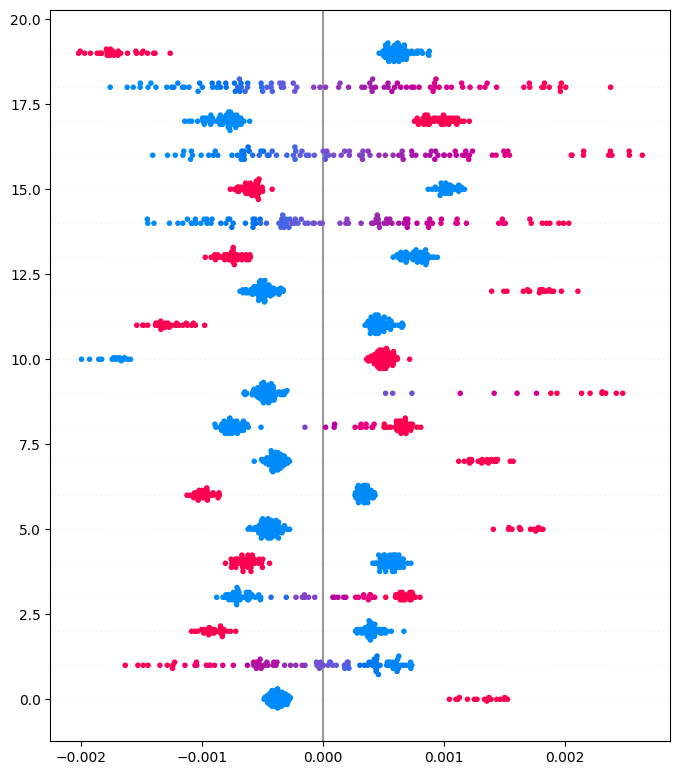

In [37]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ==============================================================================
# 1. 模型包裝器 (必要)
# ==============================================================================
class ModelWrapper(torch.nn.Module):
    def __init__(self, model, task_name):
        super(ModelWrapper, self).__init__()
        self.model = model
        self.task_name = task_name
        
    def forward(self, x):
        out = self.model(x)
        if isinstance(out, dict):
            return out[self.task_name]
        return out

# ==============================================================================
# 2. 核心繪圖函數 (包含數據展開與清洗)
# ==============================================================================
def draw_shap_beeswarm(model, train_loader, test_loader, task_name, feature_names, n_temporal, device):
    print(f"\n[{task_name}] 啟動 SHAP 分析...")
    
    # --- A. 準備資料 ---
    try:
        # 取 100 筆資料做背景與測試
        bg_data = next(iter(train_loader))[0][:100].to(device)
        test_data = next(iter(test_loader))[0][:100].to(device)
        test_data_original = next(iter(test_loader))[0][:100].cpu().numpy() # 用於顯示原始數值
    except Exception as e:
        print(f"資料讀取錯誤: {e}")
        return

    # --- B. 計算 SHAP 值 (3D) ---
    wrapped_model = ModelWrapper(model, task_name).to(device)
    wrapped_model.eval()
    
    # 關閉 CUDNN 以避免 LSTM 報錯
    with torch.backends.cudnn.flags(enabled=False):
        explainer = shap.GradientExplainer(wrapped_model, bg_data)
        shap_values = explainer.shap_values(test_data)
        
    if isinstance(shap_values, list): shap_values = shap_values[0]
    
    # 轉為 Numpy
    shap_val_np = shap_values if isinstance(shap_values, np.ndarray) else shap_values.cpu().detach().numpy()

    # --- C. 關鍵步驟：數據展開 (3D -> 2D) ---
    print(f"[{task_name}] 正在處理數據維度...")
    batch_size, seq_len, total_dim = shap_val_np.shape
    
    # 1. 時序特徵 (前 n_temporal 個) -> 展開為 D1, D2, D3
    # 轉置並重塑: [B, 3, T] -> [B, T*3]
    shap_temp = shap_val_np[:, :, :n_temporal].transpose(0, 2, 1).reshape(batch_size, -1)
    data_temp = test_data_original[:, :, :n_temporal].transpose(0, 2, 1).reshape(batch_size, -1)
    
    # 生成對應名稱 (e.g., HR_D1, HR_D2, HR_D3)
    names_temp = []
    for i in range(n_temporal):
        for d in range(seq_len):
            names_temp.append(f"{feature_names[i]}_D{d+1}")

    # 2. 靜態特徵 (後面的) -> 取平均 (因為數值在三天內不變)
    if total_dim > n_temporal:
        shap_static = np.mean(shap_val_np[:, :, n_temporal:], axis=1)
        data_static = np.mean(test_data_original[:, :, n_temporal:], axis=1)
        names_static = feature_names[n_temporal:]
    else:
        shap_static = np.empty((batch_size, 0))
        data_static = np.empty((batch_size, 0))
        names_static = []

    # 3. 合併所有特徵
    shap_final = np.hstack([shap_temp, shap_static])
    data_final = np.hstack([data_temp, data_static])
    names_final = names_temp + names_static

    # --- D. 資料清洗 (防止 Colorbar 報錯) ---
    # 將 NaN 填補為 0
    if np.isnan(data_final).any():
        print("警告: 發現 NaN，已自動填補為 0")
        data_final = np.nan_to_num(data_final, nan=0.0)
    
    # --- E. 繪圖 (Beeswarm Plot) ---
    print(f"[{task_name}] 繪製 Summary Plot...")
    plt.figure(figsize=(12, 10))
    
    shap.summary_plot(
        shap_final, 
        data_final, 
        feature_names=names_final,
        plot_type="dot",       # 指定畫蜂群圖
        max_display=20,        # 顯示前 20 重要特徵
        show=False             # 暫不顯示，以便加入標題
    )
    
    plt.title(f"SHAP Summary Plot - {task_name}", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. 執行區塊
# ==============================================================================

# 設定參數 (請依據您的資料調整)
N_TEMPORAL = 126  # 時序特徵數量 (會被展開)
N_STATIC = 145    # 靜態特徵數量 (會被平均)

if 'stl_model_dict' in globals():
    for task_name in task_name_list:
        if task_name in stl_model_dict:
            # 確保 Loader 格式正確
            t_loader = test_dataset_dict[task_name]
            if not isinstance(t_loader, DataLoader):
                t_loader = DataLoader(t_loader, batch_size=256, shuffle=False)
                
            draw_shap_beeswarm(
                model=stl_model_dict[task_name],
                train_loader=train_loader_dict[task_name],
                test_loader=t_loader,
                task_name=task_name,
                feature_names=feature_name_list, # 原始 271 個名稱
                n_temporal=N_TEMPORAL,
                device=device
            )
else:
    print("錯誤: 找不到 stl_model_dict，請確認模型已重新訓練完成。")


Processing Task: DNR
[DNR] Standard plot failed (Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.), retrying without color bar...
Saved plot to: c:\Users\USER\M1326168\MIMIC\DNR\transformer_test\shap_plots\shap_summary_DNR.png


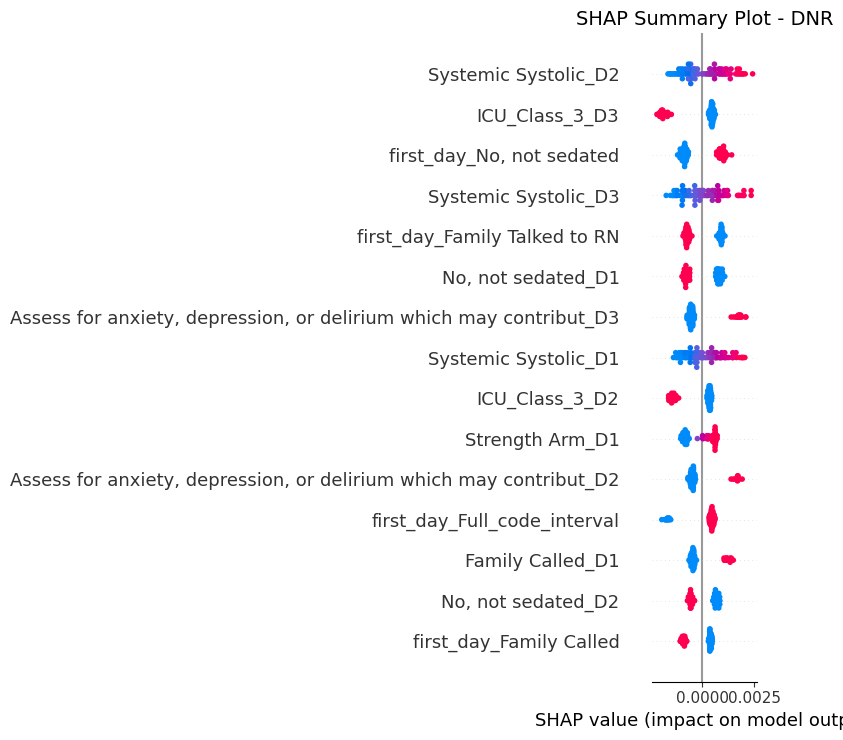


Processing Task: dod_30day


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


[dod_30day] Standard plot failed (Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.), retrying without color bar...
Saved plot to: c:\Users\USER\M1326168\MIMIC\DNR\transformer_test\shap_plots\shap_summary_dod_30day.png


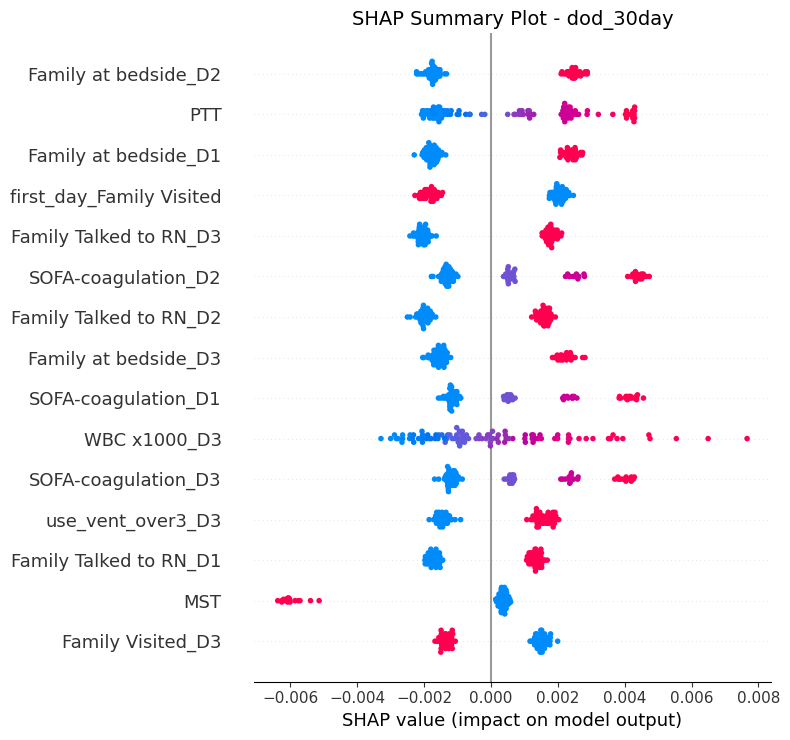


Processing Task: Vasopressor


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


[Vasopressor] Standard plot failed (Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.), retrying without color bar...
Saved plot to: c:\Users\USER\M1326168\MIMIC\DNR\transformer_test\shap_plots\shap_summary_Vasopressor.png


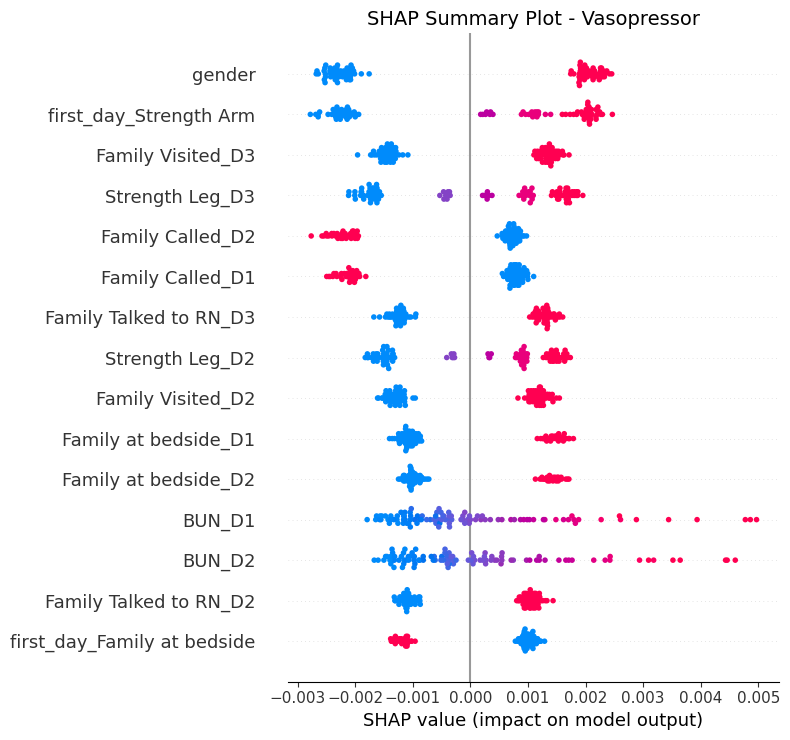

In [36]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# 1. 模型包裝器 (適配 Transformer/Hybrid 架構)
# ==============================================================================
class ModelWrapper(torch.nn.Module):
    """
    將 RNN_MTL 模型包裝起來，確保只輸出指定 task_name 的 Tensor，
    讓 SHAP GradientExplainer 可以正常運作。
    """
    def __init__(self, model, task_name):
        super(ModelWrapper, self).__init__()
        self.model = model
        self.task_name = task_name
        
    def forward(self, x):
        out = self.model(x)
        if isinstance(out, dict):
            return out[self.task_name]
        return out

# ==============================================================================
# 2. 核心計算函數 (重寫版 get_model_shap)
# ==============================================================================
def get_model_shap(model, data_X_train, data_X_test, data_X_test_original, feature_name_list, task_name, use_mini_sample=True, n_sample=100, n_temporal=103, n_static=53):
    """
    計算 SHAP 值，並將時序資料展開 (Flatten) 為 2D 格式。
    邏輯：
    - 時序特徵 (0 ~ n_temporal): 展開為 D1, D2, D3
    - 靜態特徵 (n_temporal ~ end): 取平均 (因為數值在三天內不變)
    """
    device = next(model.parameters()).device
    
    # 1. 準備數據
    if use_mini_sample:
        max_sample = 1000
        bg_data = torch.from_numpy(data_X_train[:max_sample]).float().to(device)
        test_data_tensor = torch.from_numpy(data_X_test[:n_sample]).float().to(device)
        test_data_original = data_X_test_original[:n_sample]
    else:
        bg_data = torch.from_numpy(data_X_train).float().to(device)
        test_data_tensor = torch.from_numpy(data_X_test).float().to(device)
        test_data_original = data_X_test_original

    # 2. 初始化解釋器 (加入 ModelWrapper)
    wrapped_model = ModelWrapper(model, task_name).to(device)
    wrapped_model.eval()
    
    # 【關鍵修正】關閉 CUDNN 以避免 LSTM/Transformer 計算梯度時報錯
    with torch.backends.cudnn.flags(enabled=False):
        explainer = shap.GradientExplainer(wrapped_model, bg_data)
        # 計算 SHAP 值 [Batch, Seq_Len, Features]
        shap_values = explainer.shap_values(test_data_tensor)
    
    # 處理 list 輸出
    if isinstance(shap_values, list): 
        shap_values = shap_values[0]
        
    # 轉為 Numpy
    shap_val_np = shap_values if isinstance(shap_values, np.ndarray) else shap_values.cpu().detach().numpy()
    
    # 3. 數據重塑 (Flatten Logic)
    # 使用向量化操作取代原本的雙重迴圈 (速度快 100 倍以上，且邏輯一致)
    batch_size, seq_len, total_dim = shap_val_np.shape
    
    # --- A. 處理時序特徵 (展開) ---
    # Transpose [B, 3, T] -> [B, T, 3] -> Reshape [B, T*3]
    # 排列順序: Feat1_D1, Feat1_D2, Feat1_D3, Feat2_D1...
    shap_temp = shap_val_np[:, :, :n_temporal].transpose(0, 2, 1).reshape(batch_size, -1)
    data_temp = test_data_original[:, :, :n_temporal].transpose(0, 2, 1).reshape(batch_size, -1)
    
    # 產生名稱
    flatten_feature_names = []
    for i in range(n_temporal):
        for d in range(seq_len):
            flatten_feature_names.append(f"{feature_name_list[i]}_D{d+1}")
            
    # --- B. 處理靜態特徵 (平均) ---
    if total_dim > n_temporal:
        shap_static = np.mean(shap_val_np[:, :, n_temporal:], axis=1)
        data_static = np.mean(test_data_original[:, :, n_temporal:], axis=1)
        flatten_feature_names.extend(feature_name_list[n_temporal:])
    else:
        shap_static = np.empty((batch_size, 0))
        data_static = np.empty((batch_size, 0))

    # --- C. 合併 ---
    shap_value_flatten = np.hstack([shap_temp, shap_static])
    shap_data_flatten = np.hstack([data_temp, data_static])

    # 4. 計算重要性排序
    # 重要性定義：所有樣本絕對值的平均
    feature_importance_vals = np.abs(shap_value_flatten).mean(0)
    sorted_idx = np.argsort(feature_importance_vals)[::-1]
    
    feature_important = [flatten_feature_names[i] for i in sorted_idx]
    feature_important_dict = {flatten_feature_names[i]: feature_importance_vals[i] for i in range(len(flatten_feature_names))}

    return feature_important, shap_value_flatten, shap_data_flatten, feature_important_dict

# ==============================================================================
# 3. 繪圖函數 (修正版 show_shap)
# ==============================================================================
def show_shap(shap_value_flatten, shap_data_flatten, feature_name_list, max_display=15, task_name='', plot_type='dot'):
    """
    繪圖修正版：
      - 建立 matplotlib axis 避免 colorbar 錯誤
      - 自動填補 NaN 避免繪圖失敗
      - 嘗試關閉 colorbar 作為 fallback
    """
    # 1. 資料清洗 (關鍵：防止 Colorbar 報錯)
    if np.isnan(shap_data_flatten).any():
        print(f"[{task_name}] Warning: Data contains NaN, filling with 0.")
        shap_data_flatten = np.nan_to_num(shap_data_flatten, nan=0.0)
    
    # 確保資料為數值型別
    try:
        shap_data_flatten = shap_data_flatten.astype(float)
    except:
        pass

    # 2. 設定畫布
    # 動態調整高度
    fig_height = max(6, int(max_display * 0.4) + 2)
    plt.figure(figsize=(10, fig_height))
    
    # 3. 繪圖 (Try-Except 處理 Colorbar 問題)
    try:
        # 嘗試正常繪圖
        shap.summary_plot(
            shap_value_flatten,
            shap_data_flatten,
            feature_names=feature_name_list,
            plot_type=plot_type,
            show=False,
            max_display=max_display
        )
    except Exception as e:
        print(f"[{task_name}] Standard plot failed ({e}), retrying without color bar...")
        plt.clf() # 清除畫布
        try:
            # 關閉 Colorbar 重試
            shap.summary_plot(
                shap_value_flatten,
                shap_data_flatten,
                feature_names=feature_name_list,
                plot_type=plot_type,
                show=False,
                max_display=max_display,
                color_bar=False
            )
        except TypeError:
            # 舊版 SHAP 可能不支援 color_bar 參數
            shap.summary_plot(
                shap_value_flatten,
                shap_data_flatten,
                feature_names=feature_name_list,
                plot_type="bar", # 降級為 Bar plot (最安全)
                show=False,
                max_display=max_display
            )

    plt.title(f"SHAP Summary Plot - {task_name}", fontsize=14)
    plt.tight_layout()
    
    # 4. 存檔 (選擇性)
    if task_name:
        out_dir = os.path.join(os.getcwd(), "shap_plots")
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, f"shap_summary_{task_name}.png")
        plt.savefig(out_path, bbox_inches='tight', dpi=300)
        print(f"Saved plot to: {out_path}")
        
    plt.show()

# ==============================================================================
# 4. 執行範例
# ==============================================================================
# 請確認以下參數與您訓練時一致
N_TEMPORAL = 126
N_STATIC = 145

if 'stl_model_dict' in globals():
    for task_name in task_name_list:
        if task_name in stl_model_dict:
            print(f"\nProcessing Task: {task_name}")
            imp, vals, data, imp_dict = get_model_shap(
                model=stl_model_dict[task_name],
                data_X_train=train_dataset_dict[task_name].inputs.numpy(),
                data_X_test=test_dataset_dict[task_name].inputs.numpy(),
                data_X_test_original=test_dataset_dict[task_name].inputs_original.numpy(),
                feature_name_list=feature_name_list,
                task_name=task_name,
                n_temporal=N_TEMPORAL,
                n_static=N_STATIC,
                n_sample=100
            )
            
            # 重建特徵名稱列表 (因為 get_model_shap 內部已經生成了展開後的名稱，但為了確保 show_shap 能用，我們這裡重建一次傳進去)
            # 其實 imp 變數裡面已經存了排好序的名稱，但 show_shap 需要對應原始順序的 features
            # get_model_shap 內部生成的 flatten_feature_names 我們需要把它拿出來
            # 簡單做法：我們在 get_model_shap 裡已經算好 feature_important (排序後的名稱)
            # 但 summary_plot 需要的是與 vals 對應的完整名稱列表
            
            # 重新生成完整名稱列表 (與 vals 對應)
            full_names = []
            for i in range(N_TEMPORAL):
                for d in range(3):
                    full_names.append(f"{feature_name_list[i]}_D{d+1}")
            full_names.extend(feature_name_list[N_TEMPORAL:])
            
            show_shap(vals, data, full_names, task_name=task_name)